# <center> Value at Risk

### <center> Jonatán Siracusa

# Definiciones

### Value at Risk

Es un tecnica para definir la exposicion al riesgo, y asignar el capital necesario para enfrentar esos riesgos. Se utiliza mucho en el sector bancario.

Es *"el nivel de perdidas que estamos seguros en X% que no se excederan en un horizonte de tiempo de N dias"*.

Por ejemplo, *"el 95% de los dias la cartera no va a sufrir perdidas mayores al VaR, y solo un 5% de los dias se pueden sufrir perdidas mayores"*.

O tambien, *"esta es la perdida maxima que no se va a superar, con un 95% de confianza"*.

El horizonte temporal (***h***) debe ser el necesario para lograr alguno de los siguientes:

* Liquidar la cartera
* Cobertura de la cartera


Forma parte de un Modelo de Riesgo, y debe ser complementado con herramientas para medir escenarios de cola (izq o der) como:
* Conditional VaR / Expected Shortfall / Tail Var: 
* Stress Test.


### Metodos

Tenemos los siguientes metodos:

1. **VALUACION LOCAL o PARCIAL**:
	* Metodo parametrico: ***"VaR delta-normal"*** o ***"Varianza-Covarianza"***.
		* Puede corregirse la linealidad usando *griegas* (opciones) y *convexity* (bonos): ***"VaR delta-gamma-normal"***.
		* Acciones y futuros tienen Delta constante.
		* Supuesto: **distribucion Normal de los retornos**.

	* ***VaR ajustado*** a una distribucion de probabilidad distinta de la Normal (***t-student***, por ejemplo).

2. **VALUACION TOTAL** (full valuation approach):
	* ***Simulacion historica***: 
		* Asume que todas las posibles **variaciones ya ocurrieron en el pasado** y que la **distribucion historica es identica al futuro**.

	* ***Simulacion de Monte Carlo***: 
		* La evolucion de retornos se obtiene por simulacion basada en **media ($\mu$) y volatilidad ($\sigma$)** de la **distribucion empirica** (historica).
		* Es el metodo mas robusto: pueden generarse distintos escenarios, estresando las variables de interes.
		* No es necesaria tanta informacion historica.


### Variables

Las variables de interes pueden ser:

1. Valor de una cartea o activo
2. Ganacias
3. Capital (equity)
4. Flujo de Fondos


### Riesgo vs Incertidumbre

* Incertidumbre: 
	* Supone que no podemos atribuirle ninguna distribucion de probabilidad.
	* No se conoce como puede comportarse la variable.

* Riesgo: 
	* Supone que los resultados POSIBLES DE UNA VARIABLE ALEATORIA son conocidos por su distribucion de probabilidad (no conozco su valor) y puede caracterizarse por su *valor esperado / media* ($\mu$) y su *dispersion / volatilidad* (**$\sigma$**). 
	* Es una *"variable estocastica"*.



### Riesgos de Mercado

*"La posibilidad de sufrir perdidas a causa de movimientos del mercado"*.

Se originan a partir de los efectos que factores financieros tienen sobre estas variables:
* Precios de activos (equity, bonos, commodities, etc)
* Tipo de cambio
* Tasas de interes
* Spread de creditos
* Demanda / Oferta
* Etc.

Lo medimos en terminos de ***desvio estandar o volatilidad*** (**$\sigma$**): captura la dispersion y velocidad de los movimientos de precios.

Factores:
1. **No controlo**: *volatilidad* de la variable.
2. **Controlable**: *exposicion* a la fuente de riesgo (% de la cartera).


La **Gestion de Riesgo** = *MEDIR* + *CONTROLAR EXPOSICION* (% de cartera, cobertura, etc)

Se establece el **supuesto**: ***"El pasado se repite"***

### Nivel de confianza y significatividad

**Nivel de confianza ($\alpha_c$)**: 95% ($1 - \alpha$ = 0.95)

* Seguridad con que podemos esperar no exceder la maxima perdida: **95%, 97.5%, 99%, 99.5%**.

* ***"Estamos seguros en un 95% (95 veces de 100 observaciones) que NO vamos a exceder la maxima perdida"***.

* Cuanto **mayor**, es **mas conservador** (es lo que se busca).

* Depende de la aversion al riesgo.

* VaR aumenta **exponencialmente** con el nivel de confianza.


**Nivel de significativdad ($\alpha$)**: 5% ($\alpha$ = 0.05)

* La probabilidad de cometer un error Tipo 1: rechazar una Hipotesis Falsa.


### Escalado temporal del VaR

*	Se aplica la razi cuadrada del tiempo $\sqrt{tiempo}$

*	Supone que los cambios seran i.i.d. y de acuerdo a una Normal. De no ser asi, es una aproximacion.

*	Si tenemos un $VaR_{h=1,α=5\%}$, entonces:

##### $$ VaR_{h=10,α=5\%} = VaR_{h=1,α=5\%} * \sqrt{10} $$

##### $$ VaR_{h=10,α=5\%} = VaR_{h=2,α=5\%} * \sqrt{10/2} $$

### Estimacion de la Volatilidad

Los **retornos** se calculan siempre de forma **logaritmica**.

La **volatilidad** puede estimarse de varias formas:

**1. Volatilidad **fija** (historica)**
*	Incluye toda la muestra.

**2. Volatilidad a partir de ventanas moviles**
*	Tomamos una muestra movel de *n* retornos diarios (20 o 40), y vamos excluyendo de la muestra el ultimo retorno e incluyendo el nuevo, a medida que avanzamos en la serie de precios.

$$ \sigma_t = \sqrt{ \frac{1}{n-1} * ( \sum_{i=1}^n (\bar{R} - R_i)^2 ) } $$

*	En horizontes termporales cortos, al no ser necesario centrar los datos restando la media, podemos usar la siguiente formula:

$$ \sigma_t = \sqrt{ \frac{1}{N} * ( \sum_{i=1}^n (r_i)^2 ) } $$


**3. Volatilidad a partir de **EWMA** (RiskMetrics)** 
*	*Exponentially Weighted Moving Average*. Asume que la volatilidad es heterocedastica (no constante en el tiempo) y los cambios estan autocorrelacionados.

*	La volatilidad esta condicionada por la informacion actual.

$$ \sigma_t^2 = \lambda * \sigma_{t-1}^2  +  (1 - \lambda) * r_{t-1}^2 $$

*	$\sigma_t^2:$ varianza condicional a los retornos pasados.

*	$\lambda:$ factor de persistencia temporal (0<$\lambda$<1), cuanto mas cerca a 1, mayor peso tienen las observaciones pasadas. 
*	Tipicamente se usa $\lambda = 0.94$

*	**Volatilidad en t**:

$$ \sigma_t = \sqrt{\sigma_t^2} $$

**4. Volatilidad a partir de GARCH** 
*	*Generelized Autorregressive Conditional Heteroscedasticity*. Asume que la volatilidad es heterocedastica (no constante en el tiempo) y los cambios estan autocorrelacionados.

*	Modela la volatilidad condicional al set de informacion que contiene el historial de retornos del activo.

### Portfolio dinamico / estatico

**Rebalanceado**

*	VaR supone que mantememos el portfolio constante durante el periodo.

*	La participaciones permanencen constantes (VaR dinamico): sirve para VaR de largo plazo.


**No rebalanceado**

*	Los cambios de precios cambian las participaciones en el portfolio (VaR estatico): sirve para VaR de corto plazo.


### Limitaciones del VaR

1. No especifica la cuantia de la perdida.

2. Solo expresa que el **$\alpha$%** de las veces habra perdidas mayores al VaR.

3. No especifica la distribucion de las perdidas de cola izquierda.

4. Puede tener errores de medicion: ventana historica y sigma definidos por el usuario.

5. No es subaditivo: la suma de los VaR puede ser MENOR al VaR total.

6. Debe complementarse con otras tecnicas.

# Importamos Librerias

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
import time
from datetime import datetime

import scipy.stats as stats
from scipy.stats import norm, t, probplot, jarque_bera
from scipy.optimize import minimize
from arch import arch_model

import yfinance as yf

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cufflinks as cf
cf.set_config_file(offline=True, dimensions=(800,500))
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings
warnings.simplefilter("ignore")

MARKET_DAYS_YEAR = 252


In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../"))
# project_root = os.path.abspath(os.path.join(os.getcwd(), "../"))
if project_root not in sys.path:
	sys.path.insert(0, project_root)
# Esto asegura que la raíz del proyecto (donde está src/) quede en sys.path
# Dos niveles hacia arriba desde donde está el notebook

from src.ticker_data import FinancialDataProcessor, download_yahoo_us_style
from src.utils import save_dict_to_excel_and_csv, load_dataframe_from_projectroot

# from src.VaR_GGAL.utils import descargar_datos_yf, calculate_returns, calculate_volat
# from src.VaR_GGAL.quant_fi import calcular_ema
# from src.VaR_GGAL.bloomberg_template import set_bloomberg_dark, set_bloomberg_light, get_color, get_colorscale
# from src.VaR_GGAL.visualizations import plot_series_normalizadas
# from src.VaR_GGAL.utils_save import save_file, plotly_to_png_selenium, export_plotly_png_svg_pdf, html_to_pdf, replace_plotly_with_png_in_notebook, show_plotly_as_png, export_html_to_pdf_with_chrome

# from src.VaR_GGAL.utils import download_yahoo_us_style
# from src.VaR_GGAL.ticker_data import FinancialDataProcessor

TRY_GIT=False

### Functions

In [3]:
# Función para formatear como porcentaje con dos decimales
def porcentaje_formatter(x, pos):
	return f'{x*100:.1f}%'

In [4]:
def imprimir_dict(d):
	for clave, valor in d.items():
		print(f"{clave}: {valor}")

In [5]:
hechos = pd.read_excel("hechos_relevantes.xlsx")  # ajustá el nombre del archivo
hechos['Fecha'] = pd.to_datetime(hechos['Fecha'])
# hechos.tail(8)

In [6]:
def reasignar_fechas_hechos(hechos: pd.DataFrame, fechas_grafico) -> pd.DataFrame:   
	# Convertir a datetime
	hechos = hechos.copy()
	hechos["Fecha"] = pd.to_datetime(hechos["Fecha"])
	fechas_grafico = pd.to_datetime(pd.Series(fechas_grafico)).sort_values().reset_index(drop=True)
	
	# Rango de fechas
	min_fecha = fechas_grafico.min()
	max_fecha = fechas_grafico.max()
	
	# Filtrar hechos dentro del rango
	hechos_filtrados = hechos[
		(hechos["Fecha"] >= min_fecha) & 
		(hechos["Fecha"] <= max_fecha)
	].copy()
	
	# Asignar la fecha inmediatamente anterior
	def fecha_anterior(fecha):
		anteriores = fechas_grafico[fechas_grafico <= fecha]
		if len(anteriores) == 0:
			return None  # No hay fecha anterior → se descarta
		return anteriores.iloc[-1]
	
	hechos_filtrados["FechaGraficada"] = hechos_filtrados["Fecha"].apply(fecha_anterior)
	
	# Eliminar hechos sin fecha válida
	hechos_filtrados = hechos_filtrados.dropna(subset=["FechaGraficada"])
	
	return hechos_filtrados

In [7]:
def wrap_text_for_plotly(text, max_chars_per_line):
	"""
	text (str): Texto original.
	max_chars_per_line (int): Máximo número de caracteres por línea.
	"""
	words = text.split()
	lines = []
	current_line = ""
	
	for word in words:
		# Si agregamos la palabra supera el límite
		if len(current_line) + len(word) + 1 > max_chars_per_line:
			if current_line:
				lines.append(current_line)
			current_line = word  # nueva línea empieza con la palabra actual
		else:
			if current_line:
				current_line += " " + word
			else:
				current_line = word
	
	# Agregamos la última línea
	if current_line:
		lines.append(current_line)
	
	# Unimos todas las líneas con <br> para Plotly
	return "<br>".join(lines)

In [8]:
from __future__ import annotations
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path
import unicodedata
import re

def _slugify(text: str) -> str:
    """Convierte a nombre de archivo seguro (sin acentos ni símbolos raros)."""
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text).strip("_")
    return re.sub(r"_+", "_", text)

def save_plotly_image(fig, formato: str = "png", calidad: int = 3) -> str:
    """
    Guarda una figura de Plotly como imagen de alta calidad.

    Parámetros
    ----------
    fig : plotly.graph_objs._figure.Figure
        La figura de Plotly a exportar. Debe tener `fig.layout.meta["ticker"]`.
        Opcionalmente, `fig.layout.meta["fig_name"]` para nombrar la figura.
        Si no hay `fig_name`, se usa el título de la figura; si no, 'fig'.
    formato : str
        'png' | 'jpg' | 'jpeg' | 'webp' | 'svg' | 'pdf'
    calidad : int
        Factor de escala para formatos raster (1–5 recomendado). Para vectores (svg/pdf) se ignora.

    Retorna
    -------
    str : ruta del archivo generado.
    """
    # --- Validación de formato
    fmt = (formato or "png").lower().lstrip(".")
    valid = {"png", "jpg", "jpeg", "webp", "svg", "pdf"}
    if fmt not in valid:
        raise ValueError(f"Formato no soportado: {fmt}. Usa uno de {sorted(valid)}")

    # --- Extraer ticker y nombre de figura
    meta = getattr(fig.layout, "meta", None) or {}
    ticker = str(meta.get("ticker", "")).strip()
    if not ticker:
        # Si no lo encuentra en meta, intenta deducirlo de trace.name (fallback suave)
        names = [getattr(tr, "name", "") for tr in getattr(fig, "data", []) if getattr(tr, "name", "")]
        ticker = names[0] if names else "TICKER"

    fig_name = str(meta.get("fig_name", "")).strip()
    if not fig_name:
        title = getattr(fig.layout, "title", None)
        fig_name = getattr(title, "text", None) or "fig"

    # --- Componer nombre de archivo
    ts = datetime.now(ZoneInfo("America/Sao_Paulo")).strftime("%Y%m%d_%H%M%S")
    base = f"{_slugify(fig_name)}_{_slugify(ticker)}_{ts}"
    outfile = Path(f"{base}.{fmt}")

    # --- Tamaño y escala
    width = getattr(fig.layout, "width", None) or 1600
    height = getattr(fig.layout, "height", None) or 900
    scale = max(1, min(int(calidad or 3), 10))

    # --- Exportar (Kaleido)
    if fmt in {"png", "jpg", "jpeg", "webp"}:
        fig.write_image(str(outfile), format=fmt, width=width, height=height, scale=scale)
    else:  # svg/pdf (vectoriales), la "calidad" no aplica
        fig.write_image(str(outfile), format=fmt, width=width, height=height)

    return str(outfile)


In [9]:
# -*- coding: utf-8 -*-
"""
Analítica de retornos diarios:
1) Tabla por percentil con frecuencia y valores incluidos.
2) Conteo de ruedas alcistas/bajistas/neutras.
3) Matriz de transiciones (U→U, U→D, D→D, D→U), ignorando neutras.
4) Conteo de rachas de 3 y 4 días, en variantes:
   - windows_k: número de ventanas superpuestas de tamaño k con todas U (o todas D)
   - runs_exact_k: cantidad de runs (segmentos) de longitud exactamente k
   - runs_at_least_k: cantidad de runs de longitud ≥ k
"""

import numpy as np
import pandas as pd

# =========================
# Utilidades generales
# =========================
def _sign_series(returns: pd.Series) -> pd.Series:
    """
    Devuelve una serie con:
      +1 si retorno > 0 (Up / U)
      -1 si retorno < 0 (Down / D)
       0 si retorno == 0 o NaN
    """
    s = returns.copy()
    s = s.astype(float)
    s = s.fillna(0.0)
    out = pd.Series(np.where(s > 0, 1, np.where(s < 0, -1, 0)), index=s.index)
    return out

def _run_lengths(mask: pd.Series) -> np.ndarray:
    """
    Dado un mask booleano (True/False), devuelve un array con las longitudes de
    cada run de True consecutivos (los False cortan la racha).
    """
    arr = mask.to_numpy(dtype=int)
    # Delimitamos con ceros para detectar inicios y finales de runs de True
    padded = np.r_[0, arr, 0]
    diff = np.diff(padded)
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]
    lengths = ends - starts
    return lengths

# =========================
# 1) Tabla por percentil
# =========================
def tabla_percentiles(returns: pd.Series, q: int = 100, round_values: int | None = 6) -> pd.DataFrame:
    """
    Construye una tabla por percentil (1..q).
    Método: rank percentil por observación y binning a enteros 1..q.
    Columns:
      - percentile: 1..q
      - count: cantidad de observaciones en ese percentil
      - freq: proporción del total
      - min, max: valores mínimos y máximos del percentil
      - values: lista de retornos incluidos
      - pct_range: rango de percentil (e.g., '0.00%–1.00%')
    """
    r = pd.Series(returns).dropna().astype(float)
    if r.empty:
        return pd.DataFrame(columns=["percentile","count","freq","min","max","values","pct_range"])

    df = pd.DataFrame({"ret": r})
    df["pct_rank"]   = df["ret"].rank(pct=True, method="average")
    df["percentile"] = (np.ceil(df["pct_rank"] * q)).astype(int).clip(1, q)

    grp = df.groupby("percentile", sort=True)
    out = grp["ret"].agg(
        count="size",
        min="min",
        max="max"
    ).reset_index()

    total = len(df)
    out["freq"] = out["count"] / total
    # Lista de valores en cada percentil
    vals = grp["ret"].apply(lambda s: np.round(s, round_values).tolist() if round_values is not None else s.tolist())
    out = out.merge(vals.rename("values"), on="percentile", how="left")

    # Rango de percentil (informativo)
    out["pct_range"] = out["percentile"].apply(lambda p: f"{(p-1)/q:.2%}–{p/q:.2%}")

    # Reordenamos columnas
    out = out[["percentile", "pct_range", "count", "freq", "min", "max", "values"]]
    return out

# =========================
# 2) Conteo alcistas/bajistas
# =========================
def conteo_alcistas_bajistas(returns: pd.Series) -> dict:
    """
    Devuelve un dict con conteos de días:
      - up: retornos > 0
      - down: retornos < 0
      - zero: retornos == 0
      - total: total de observaciones no nulas (incluye ceros)
    """
    r = pd.Series(returns).dropna().astype(float)
    up   = int((r > 0).sum())
    down = int((r < 0).sum())
    zero = int((r == 0).sum())
    total = int(len(r))
    return {"up": up, "down": down, "zero": zero, "total": total}

# =========================
# 3) Matriz de transiciones U/D
# =========================
def transiciones_ud(returns: pd.Series) -> dict:
    """
    Cuenta transiciones entre días consecutivos ignorando neutros (0).
    Devuelve:
      - U_to_U, U_to_D, D_to_D, D_to_U
      - total_pairs: número de pares válidos considerados
    """
    s = _sign_series(returns)
    curr = s.iloc[:-1]
    nxt  = s.shift(-1).iloc[:-1]

    mask = (curr != 0) & (nxt != 0)
    curr = curr[mask]
    nxt  = nxt[mask]

    U_to_U = int(((curr == 1) & (nxt == 1)).sum())
    U_to_D = int(((curr == 1) & (nxt == -1)).sum())
    D_to_D = int(((curr == -1) & (nxt == -1)).sum())
    D_to_U = int(((curr == -1) & (nxt == 1)).sum())

    return {
        "U_to_U": U_to_U,
        "U_to_D": U_to_D,
        "D_to_D": D_to_D,
        "D_to_U": D_to_U,
        "total_pairs": int(mask.sum())
    }

# =========================
# 4) Rachas (3 y 4 ruedas)
# =========================
def rachas_k(returns: pd.Series, k: int) -> dict:
    """
    Para k (p.ej., 3 o 4), devuelve:
      - windows_up_k / windows_down_k: # de ventanas superpuestas de tamaño k con todas U (o D)
      - runs_exact_up_k / runs_exact_down_k: # de runs de longitud exactamente k (no superpuestos)
      - runs_at_least_up_k / runs_at_least_down_k: # de runs de longitud ≥ k
    """
    s = _sign_series(returns)
    up_mask   = (s == 1)
    down_mask = (s == -1)

    # Ventanas superpuestas de tamaño k con todas True
    windows_up_k   = int(up_mask.rolling(k).sum().eq(k).sum())
    windows_down_k = int(down_mask.rolling(k).sum().eq(k).sum())

    # Runs (segmentos) y sus longitudes
    up_lengths   = _run_lengths(up_mask)
    down_lengths = _run_lengths(down_mask)

    runs_exact_up_k      = int(np.sum(up_lengths == k))
    runs_exact_down_k    = int(np.sum(down_lengths == k))
    runs_at_least_up_k   = int(np.sum(up_lengths >= k))
    runs_at_least_down_k = int(np.sum(down_lengths >= k))

    return {
        f"windows_up_{k}": windows_up_k,
        f"windows_down_{k}": windows_down_k,
        f"runs_exact_up_{k}": runs_exact_up_k,
        f"runs_exact_down_{k}": runs_exact_down_k,
        f"runs_at_least_up_{k}": runs_at_least_up_k,
        f"runs_at_least_down_{k}": runs_at_least_down_k,
    }

# =========================
# Función de alto nivel
# =========================
def analizar_retorno_diario(returns: pd.Series, percentiles: int = 100) -> dict:
    """
    Ejecuta todo el flujo y retorna un diccionario con:
      - tabla_percentiles (DataFrame)
      - conteos_ud (dict)
      - transiciones (dict)
      - rachas_3 (dict)
      - rachas_4 (dict)
    """
    out = {}
    out["tabla_percentiles"] = tabla_percentiles(returns, q=percentiles, round_values=6)
    out["conteos_ud"] = conteo_alcistas_bajistas(returns)
    out["transiciones"] = transiciones_ud(returns)
    out["rachas_3"] = rachas_k(returns, 3)
    out["rachas_4"] = rachas_k(returns, 4)
    return out

# # =========================
# # Ejemplo de uso
# # =========================
# if __name__ == "__main__":
#     # EJEMPLO: simulación (reemplazá por tu serie real: 'returns' = pd.Series(...))
#     np.random.seed(42)
#     idx = pd.bdate_range("2024-01-01", "2024-12-31")
#     simulated_returns = pd.Series(np.random.normal(0, 0.01, size=len(idx)), index=idx)

#     resultados = analizar_retorno_diario(simulated_returns, percentiles=100)

#     print("\n=== (1) Tabla por percentil (primeras filas) ===")
#     print(resultados["tabla_percentiles"].head(10).to_string(index=False))

#     print("\n=== (2) Conteos U/D/0 ===")
#     print(resultados["conteos_ud"])

#     print("\n=== (3) Transiciones U/D ===")
#     print(resultados["transiciones"])

#     print("\n=== (4) Rachas de 3 ===")
#     print(resultados["rachas_3"])

#     print("\n=== (4) Rachas de 4 ===")
#     print(resultados["rachas_4"])

# =========================
# Exportación a Excel
# =========================
def _auto_fit_columns(ws, df, writer, wrap_cols=None):
    """Ajuste de ancho de columnas según contenido."""
    if wrap_cols is None:
        wrap_cols = []
    workbook  = writer.book
    wrap_fmt  = workbook.add_format({"text_wrap": True, "valign": "top"})
    default_fmt = workbook.add_format({"valign": "top"})

    for i, col in enumerate(df.columns):
        # Longitud máxima entre nombre de columna y celdas
        series_as_str = df[col].astype(str)
        max_len = max([len(str(col))] + series_as_str.map(len).tolist())
        width = min(max(10, max_len + 2), 60)  # límite razonable
        fmt = wrap_fmt if col in wrap_cols else default_fmt
        ws.set_column(i, i, width, fmt)

def exportar_resultados_excel(resultados: dict, ruta_archivo: str = "analisis_retornos.xlsx"):
    """
    Crea un Excel con hojas:
      - Percentiles
      - Conteos_UD
      - Transiciones
      - Rachas_3
      - Rachas_4
    """
    with pd.ExcelWriter(ruta_archivo, engine="xlsxwriter") as writer:
        wb = writer.book
        header_fmt = wb.add_format({"bold": True, "bg_color": "#F2F2F2", "border": 1})
        percent_fmt = wb.add_format({"num_format": "0.00%", "valign": "top"})
        int_fmt = wb.add_format({"num_format": "0", "valign": "top"})
        float_fmt = wb.add_format({"num_format": "0.000000", "valign": "top"})

        # --- Percentiles ---
        dfp = resultados["tabla_percentiles"].copy()
        # 'values' como texto multilínea
        dfp["values"] = dfp["values"].apply(lambda vs: "\n".join(map(str, vs)))
        dfp.to_excel(writer, sheet_name="Percentiles", index=False)
        ws = writer.sheets["Percentiles"]
        # Encabezado y formatos por columna
        for col_idx, _ in enumerate(dfp.columns):
            ws.write(0, col_idx, dfp.columns[col_idx], header_fmt)
        # Aplicar formato a columnas específicas
        col_map = { "freq": percent_fmt, "min": float_fmt, "max": float_fmt }
        for j, col in enumerate(dfp.columns):
            if col in col_map:
                ws.set_column(j, j, None, col_map[col])
        _auto_fit_columns(ws, dfp, writer, wrap_cols=["values"])
        ws.freeze_panes(1, 0)
        ws.autofilter(0, 0, len(dfp), dfp.shape[1]-1)

        # --- Conteos U/D ---
        dfc = pd.DataFrame([resultados["conteos_ud"]])
        dfc.to_excel(writer, sheet_name="Conteos_UD", index=False)
        ws = writer.sheets["Conteos_UD"]
        for col_idx, _ in enumerate(dfc.columns):
            ws.write(0, col_idx, dfc.columns[col_idx], header_fmt)
            ws.set_column(col_idx, col_idx, None, int_fmt)
        _auto_fit_columns(ws, dfc, writer)
        ws.freeze_panes(1, 0)

        # --- Transiciones ---
        dft = pd.DataFrame([resultados["transiciones"]])
        dft.to_excel(writer, sheet_name="Transiciones", index=False)
        ws = writer.sheets["Transiciones"]
        for col_idx, _ in enumerate(dft.columns):
            ws.write(0, col_idx, dft.columns[col_idx], header_fmt)
            ws.set_column(col_idx, col_idx, None, int_fmt)
        _auto_fit_columns(ws, dft, writer)
        ws.freeze_panes(1, 0)

        # --- Rachas 3 ---
        dfr3 = pd.DataFrame([resultados["rachas_3"]])
        dfr3.to_excel(writer, sheet_name="Rachas_3", index=False)
        ws = writer.sheets["Rachas_3"]
        for col_idx, _ in enumerate(dfr3.columns):
            ws.write(0, col_idx, dfr3.columns[col_idx], header_fmt)
            ws.set_column(col_idx, col_idx, None, int_fmt)
        _auto_fit_columns(ws, dfr3, writer)
        ws.freeze_panes(1, 0)

        # --- Rachas 4 ---
        dfr4 = pd.DataFrame([resultados["rachas_4"]])
        dfr4.to_excel(writer, sheet_name="Rachas_4", index=False)
        ws = writer.sheets["Rachas_4"]
        for col_idx, _ in enumerate(dfr4.columns):
            ws.write(0, col_idx, dfr4.columns[col_idx], header_fmt)
            ws.set_column(col_idx, col_idx, None, int_fmt)
        _auto_fit_columns(ws, dfr4, writer)
        ws.freeze_panes(1, 0)

    return ruta_archivo


In [10]:
# # -*- coding: utf-8 -*-
# """
# Analítica de retornos diarios + Exportación a Excel (frecuencia ABSOLUTA en percentiles)
# Requiere: pandas, numpy, xlsxwriter
# pip install pandas numpy xlsxwriter
# """

# import numpy as np
# import pandas as pd

# # =========================
# # Utilidades generales
# # =========================
# def _sign_series(returns: pd.Series) -> pd.Series:
#     s = returns.copy().astype(float)
#     s = s.fillna(0.0)
#     return pd.Series(np.where(s > 0, 1, np.where(s < 0, -1, 0)), index=s.index)

# def _run_lengths(mask: pd.Series) -> np.ndarray:
#     arr = mask.to_numpy(dtype=int)
#     padded = np.r_[0, arr, 0]
#     diff = np.diff(padded)
#     starts = np.where(diff == 1)[0]
#     ends   = np.where(diff == -1)[0]
#     return ends - starts

# # =========================
# # 1) Tabla por percentil (frecuencia ABSOLUTA)
# # =========================
# def tabla_percentiles(returns: pd.Series, q: int = 100, round_values: int = 6) -> pd.DataFrame:
#     r = pd.Series(returns).dropna().astype(float)
#     if r.empty:
#         return pd.DataFrame(columns=["percentile","pct_range","freq_abs","min","max","values"])

#     df = pd.DataFrame({"ret": r})
#     df["pct_rank"]   = df["ret"].rank(pct=True, method="average")
#     df["percentile"] = (np.ceil(df["pct_rank"] * q)).astype(int).clip(1, q)

#     grp = df.groupby("percentile", sort=True)
#     agg = grp["ret"].agg(count="size", min="min", max="max").reset_index()

#     vals = grp["ret"].apply(lambda s: np.round(s, round_values).tolist())
#     out = agg.merge(vals.rename("values"), on="percentile", how="left")

#     out["pct_range"] = out["percentile"].apply(lambda p: f"{(p-1)/q:.2%}–{p/q:.2%}")
#     out = out.rename(columns={"count": "freq_abs"})
#     out = out[["percentile", "pct_range", "freq_abs", "min", "max", "values"]]
#     return out

# # =========================
# # 2) Conteo alcistas/bajistas
# # =========================
# def conteo_alcistas_bajistas(returns: pd.Series) -> dict:
#     r = pd.Series(returns).dropna().astype(float)
#     return {
#         "up":   int((r > 0).sum()),
#         "down": int((r < 0).sum()),
#         "zero": int((r == 0).sum()),
#         "total": int(len(r))
#     }

# # =========================
# # 3) Transiciones U/D
# # =========================
# def transiciones_ud(returns: pd.Series) -> dict:
#     s = _sign_series(returns)
#     curr = s.iloc[:-1]
#     nxt  = s.shift(-1).iloc[:-1]
#     mask = (curr != 0) & (nxt != 0)
#     curr = curr[mask]; nxt = nxt[mask]

#     U_to_U = int(((curr == 1) & (nxt == 1)).sum())
#     U_to_D = int(((curr == 1) & (nxt == -1)).sum())
#     D_to_D = int(((curr == -1) & (nxt == -1)).sum())
#     D_to_U = int(((curr == -1) & (nxt == 1)).sum())

#     return {"U_to_U": U_to_U, "U_to_D": U_to_D, "D_to_D": D_to_D, "D_to_U": D_to_U, "total_pairs": int(mask.sum())}

# # =========================
# # 4) Rachas (k)
# # =========================
# def rachas_k(returns: pd.Series, k: int) -> dict:
#     s = _sign_series(returns)
#     up_mask   = (s == 1)
#     down_mask = (s == -1)

#     windows_up_k   = int(up_mask.rolling(k).sum().eq(k).sum())
#     windows_down_k = int(down_mask.rolling(k).sum().eq(k).sum())

#     up_lengths   = _run_lengths(up_mask)
#     down_lengths = _run_lengths(down_mask)

#     return {
#         f"windows_up_{k}": windows_up_k,
#         f"windows_down_{k}": windows_down_k,
#         f"runs_exact_up_{k}": int(np.sum(up_lengths == k)),
#         f"runs_exact_down_{k}": int(np.sum(down_lengths == k)),
#         f"runs_at_least_up_{k}": int(np.sum(up_lengths >= k)),
#         f"runs_at_least_down_{k}": int(np.sum(down_lengths >= k)),
#     }

# # =========================
# # Función de alto nivel
# # ========================
# def analizar_retorno_diario(returns: pd.Series, percentiles: int = 100) -> dict:
#     out = {}
#     out["tabla_percentiles"] = tabla_percentiles(returns, q=percentiles, round_values=6)
#     out["conteos_ud"] = conteo_alcistas_bajistas(returns)
#     out["transiciones"] = transiciones_ud(returns)
#     out["rachas_3"] = rachas_k(returns, 3)
#     out["rachas_4"] = rachas_k(returns, 4)
#     return out

# # =========================
# # Exportación a Excel
# # =========================
# def _auto_fit_columns(ws, df, writer, wrap_cols=None):
#     if wrap_cols is None:
#         wrap_cols = []
#     workbook  = writer.book
#     wrap_fmt  = workbook.add_format({"text_wrap": True, "valign": "top"})
#     default_fmt = workbook.add_format({"valign": "top"})

#     for i, col in enumerate(df.columns):
#         series_as_str = df[col].astype(str)
#         max_len = max([len(str(col))] + series_as_str.map(len).tolist())
#         width = min(max(10, max_len + 2), 60)
#         fmt = wrap_fmt if col in wrap_cols else default_fmt
#         ws.set_column(i, i, width, fmt)

# def exportar_resultados_excel(resultados: dict, ruta_archivo: str = "analisis_retornos.xlsx"):
#     with pd.ExcelWriter(ruta_archivo, engine="xlsxwriter") as writer:
#         wb = writer.book
#         header_fmt = wb.add_format({"bold": True, "bg_color": "#F2F2F2", "border": 1})
#         int_fmt = wb.add_format({"num_format": "0", "valign": "top"})
#         float_fmt = wb.add_format({"num_format": "0.000000", "valign": "top"})

#         # --- Percentiles (freq_abs) ---
#         dfp = resultados["tabla_percentiles"].copy()
#         dfp["values"] = dfp["values"].apply(lambda vs: "\n".join(map(str, vs)))
#         dfp.to_excel(writer, sheet_name="Percentiles", index=False)
#         ws = writer.sheets["Percentiles"]
#         for col_idx, _ in enumerate(dfp.columns):
#             ws.write(0, col_idx, dfp.columns[col_idx], header_fmt)
#         # Formatos
#         for j, col in enumerate(dfp.columns):
#             if col in ("freq_abs",):
#                 ws.set_column(j, j, None, int_fmt)
#             if col in ("min", "max"):
#                 ws.set_column(j, j, None, float_fmt)
#         _auto_fit_columns(ws, dfp, writer, wrap_cols=["values"])
#         ws.freeze_panes(1, 0)
#         ws.autofilter(0, 0, len(dfp), dfp.shape[1]-1)

#         # --- Conteos U/D ---
#         dfc = pd.DataFrame([resultados["conteos_ud"]])
#         dfc.to_excel(writer, sheet_name="Conteos_UD", index=False)
#         ws = writer.sheets["Conteos_UD"]
#         for col_idx, _ in enumerate(dfc.columns):
#             ws.write(0, col_idx, dfc.columns[col_idx], header_fmt)
#             ws.set_column(col_idx, col_idx, None, int_fmt)
#         _auto_fit_columns(ws, dfc, writer)
#         ws.freeze_panes(1, 0)

#         # --- Transiciones ---
#         dft = pd.DataFrame([resultados["transiciones"]])
#         dft.to_excel(writer, sheet_name="Transiciones", index=False)
#         ws = writer.sheets["Transiciones"]
#         for col_idx, _ in enumerate(dft.columns):
#             ws.write(0, col_idx, dft.columns[col_idx], header_fmt)
#             ws.set_column(col_idx, col_idx, None, int_fmt)
#         _auto_fit_columns(ws, dft, writer)
#         ws.freeze_panes(1, 0)

#         # --- Rachas 3 ---
#         dfr3 = pd.DataFrame([resultados["rachas_3"]])
#         dfr3.to_excel(writer, sheet_name="Rachas_3", index=False)
#         ws = writer.sheets["Rachas_3"]
#         for col_idx, _ in enumerate(dfr3.columns):
#             ws.write(0, col_idx, dfr3.columns[col_idx], header_fmt)
#             ws.set_column(col_idx, col_idx, None, int_fmt)
#         _auto_fit_columns(ws, dfr3, writer)
#         ws.freeze_panes(1, 0)

#         # --- Rachas 4 ---
#         dfr4 = pd.DataFrame([resultados["rachas_4"]])
#         dfr4.to_excel(writer, sheet_name="Rachas_4", index=False)
#         ws = writer.sheets["Rachas_4"]
#         for col_idx, _ in enumerate(dfr4.columns):
#             ws.write(0, col_idx, dfr4.columns[col_idx], header_fmt)
#             ws.set_column(col_idx, col_idx, None, int_fmt)
#         _auto_fit_columns(ws, dfr4, writer)
#         ws.freeze_panes(1, 0)

#     return ruta_archivo

# # =========================
# # Ejemplo de uso
# # =========================
# if __name__ == "__main__":
#     np.random.seed(42)
#     idx = pd.bdate_range("2024-01-01", "2024-12-31")
#     returns = pd.Series(np.random.normal(0, 0.01, size=len(idx)), index=idx)

#     resultados = analizar_retorno_diario(returns, percentiles=100)
#     archivo = exportar_resultados_excel(resultados, ruta_archivo="analisis_retornos.xlsx")
#     print(f"Excel generado: {archivo}")


In [11]:
import numpy as np
import pandas as pd

def tabla_frecuencias(hist_values, bin_edges, drop_empty=False, dec=6):
    """
    Genera una tabla de frecuencias a partir de la salida de np.histogram
    (hist_values, bin_edges) con density=False.

    Columnas:
      - bin_left, bin_right, bin_width, bin_center (marca de clase)
      - freq_abs, freq_rel, freq_rel_pct
      - cum_abs, cum_rel, cum_rel_pct
      - density  (= freq_abs / (N * bin_width))  útil si los bins tienen ancho variable
      - intervalo (string con [a,b) y el último [a,b])

    Parámetros:
      drop_empty: si True, elimina filas con freq_abs == 0
      dec: decimales para redondeo de columnas flotantes (solo presentación)
    """
    hist_values = np.asarray(hist_values, dtype=float)
    bin_edges   = np.asarray(bin_edges, dtype=float)

    # Bordes y medidas del bin
    left   = bin_edges[:-1]
    right  = bin_edges[1:]
    width  = right - left
    center = (left + right) / 2

    # Total de observaciones (debería coincidir con len(datos) sin NaN)
    N = hist_values.sum()

    # Frecuencias
    freq_abs = hist_values.astype(int)
    freq_rel = (freq_abs / N) if N > 0 else np.zeros_like(freq_abs, dtype=float)

    # Acumuladas
    cum_abs = np.cumsum(freq_abs)
    cum_rel = np.cumsum(freq_rel)

    # Densidad por bin (coincide con pdf aprox. si density=False y ancho variable)
    density = np.divide(freq_abs, (N * width), out=np.zeros_like(width, dtype=float), where=width>0)

    # Intervalos como texto: [a,b) salvo el último [a,b]
    intervalos = []
    for i, (a, b) in enumerate(zip(left, right)):
        cerrado_derecha = (i == len(right) - 1)  # último bin
        etiqueta = f"[{a:.{dec}f},{b:.{dec}f}" + ("]" if cerrado_derecha else ")")
        intervalos.append(etiqueta)

    df = pd.DataFrame({
        "bin_left": left,
        "bin_right": right,
        "bin_width": width,
        "bin_center": center,
        "freq_abs": freq_abs,
        "freq_rel": freq_rel,
        "freq_rel_pct": freq_rel * 100,
        "cum_abs": cum_abs,
        "cum_rel": cum_rel,
        "cum_rel_pct": cum_rel * 100,
        "density": density,
        "intervalo": intervalos,
    })

    if drop_empty:
        df = df[df["freq_abs"] > 0].reset_index(drop=True)

    # Redondeo para visualización (no afecta cálculos aguas arriba)
    float_cols = ["bin_left","bin_right","bin_width","bin_center",
                  "freq_rel","freq_rel_pct","cum_rel","cum_rel_pct","density"]
    df[float_cols] = df[float_cols].round(dec)

    return df

# === Ejemplo de uso con tus variables ya calculadas ===
# hist_values, bin_edges = np.histogram(datos, bins=100, density=False)
# bin_width = bin_edges[1] - bin_edges[0]  # (si los bins son uniformes)
# df_freq = tabla_frecuencias(hist_values, bin_edges, drop_empty=False, dec=6)
# print(df_freq.head(10))
# df_freq.to_excel("tabla_frecuencias_histograma.xlsx", index=False)


In [12]:
# Requiere: pandas, numpy, xlsxwriter
# pip install pandas numpy xlsxwriter

import numpy as np
import pandas as pd

def exportar_frecuencias_histograma_excel(
    hist_values,
    bin_edges,
    ruta_excel: str = "tabla_frecuencias_histograma.xlsx",
    sheet_name: str = "Frecuencias",
    dec: int = 6,
    drop_empty: bool = False,
    incluir_relativas: bool = True,
    incluir_density: bool = True,
    autofiltro: bool = True,
):
    """
    Exporta a Excel la tabla de frecuencias construida a partir de np.histogram(datos, ..., density=False).

    Parámetros
    ----------
    hist_values : array-like
        Conteos por bin (salida de np.histogram con density=False).
    bin_edges : array-like
        Bordes de los bins (len = len(hist_values) + 1).
    ruta_excel : str
        Ruta del archivo .xlsx a crear.
    sheet_name : str
        Nombre de la hoja dentro del Excel.
    dec : int
        Decimales para presentación (no cambia los cálculos).
    drop_empty : bool
        Si True, elimina filas con freq_abs == 0 antes de exportar.
    incluir_relativas : bool
        Si False, no incluye columnas freq_rel ni cum_rel.
    incluir_density : bool
        Si False, no incluye la columna density.
    autofiltro : bool
        Si True, agrega autofiltro en la hoja.

    Returns
    -------
    (ruta_excel, df) : tuple[str, pandas.DataFrame]
        Ruta final del archivo y el DataFrame exportado.
    """
    hist_values = np.asarray(hist_values)
    bin_edges   = np.asarray(bin_edges)

    if hist_values.ndim != 1 or bin_edges.ndim != 1 or len(bin_edges) != len(hist_values) + 1:
        raise ValueError("Entradas inválidas: bin_edges debe tener len(hist_values) + 1.")

    left   = bin_edges[:-1].astype(float)
    right  = bin_edges[1:].astype(float)
    width  = right - left
    center = (left + right) / 2

    freq_abs = hist_values.astype(int)
    N = int(freq_abs.sum())

    if N > 0:
        freq_rel = freq_abs / N
        cum_abs  = np.cumsum(freq_abs)
        cum_rel  = cum_abs / N
    else:
        freq_rel = np.zeros_like(freq_abs, dtype=float)
        cum_abs  = np.cumsum(freq_abs)
        cum_rel  = np.zeros_like(freq_abs, dtype=float)

    # Densidad por bin (útil con anchos variables)
    density = np.divide(
        freq_abs, (N * width),
        out=np.zeros_like(width, dtype=float),
        where=(width > 0) & (N > 0)
    )

    # Intervalos como string: [a,b) excepto el último [a,b]
    intervalos = [
        f"[{a:.{dec}f},{b:.{dec}f}" + ("]" if i == len(right) - 1 else ")")
        for i, (a, b) in enumerate(zip(left, right))
    ]

    data = {
        "bin_left": left,
        "bin_right": right,
        "bin_width": width,
        "bin_center": center,
        "freq_abs": freq_abs,
        "cum_abs": cum_abs,
        "intervalo": intervalos,
    }
    if incluir_relativas:
        data["freq_rel"] = freq_rel
        data["cum_rel"]  = cum_rel
    if incluir_density:
        data["density"]  = density

    df = pd.DataFrame(data)

    if drop_empty:
        df = df[df["freq_abs"] > 0].reset_index(drop=True)

    # Redondeo visual (no afecta cálculos ya hechos)
    float_cols_base = {"bin_left","bin_right","bin_width","bin_center"}
    float_cols_opt  = set()
    if incluir_relativas:
        float_cols_opt.update({"freq_rel","cum_rel"})
    if incluir_density:
        float_cols_opt.update({"density"})
    float_cols = list(float_cols_base | float_cols_opt)
    if float_cols:
        df[float_cols] = df[float_cols].round(dec)

    # ---- Exportación a Excel con formatos ----
    with pd.ExcelWriter(ruta_excel, engine="xlsxwriter") as writer:
        df.to_excel(writer, sheet_name=sheet_name, index=False)
        ws = writer.sheets[sheet_name]
        wb = writer.book

        header_fmt = wb.add_format({"bold": True, "bg_color": "#F2F2F2", "border": 1})
        pct_fmt    = wb.add_format({"num_format": "0.00%", "valign": "top"})
        float_fmt  = wb.add_format({"num_format": "0." + "0"*dec, "valign": "top"})
        int_fmt    = wb.add_format({"num_format": "0", "valign": "top"})
        wrap_fmt   = wb.add_format({"text_wrap": True, "valign": "top"})

        # Encabezados con estilo
        for j, c in enumerate(df.columns):
            ws.write(0, j, c, header_fmt)

        col_idx = {c: i for i, c in enumerate(df.columns)}

        # Formatos por columna
        for c in ["bin_left","bin_right","bin_width","bin_center"]:
            if c in col_idx:
                ws.set_column(col_idx[c], col_idx[c], 12, float_fmt)
        if "density" in col_idx:
            ws.set_column(col_idx["density"], col_idx["density"], 12, float_fmt)
        if "freq_abs" in col_idx:
            ws.set_column(col_idx["freq_abs"], col_idx["freq_abs"], 10, int_fmt)
        if "cum_abs" in col_idx:
            ws.set_column(col_idx["cum_abs"], col_idx["cum_abs"], 10, int_fmt)
        if "freq_rel" in col_idx:
            ws.set_column(col_idx["freq_rel"], col_idx["freq_rel"], 10, pct_fmt)
        if "cum_rel" in col_idx:
            ws.set_column(col_idx["cum_rel"], col_idx["cum_rel"], 10, pct_fmt)
        if "intervalo" in col_idx:
            ws.set_column(col_idx["intervalo"], col_idx["intervalo"], 35, wrap_fmt)

        # Auto-ajuste simple de anchos (sin perder formato asignado)
        for c, i in col_idx.items():
            max_len = max(len(c), int(df[c].astype(str).map(len).max()))
            ws.set_column(i, i, min(max(10, max_len + 2), 50))

        ws.freeze_panes(1, 0)
        if autofiltro:
            ws.autofilter(0, 0, len(df), len(df.columns)-1)

    return ruta_excel, df


In [13]:
def empirical_log_to_simple_metrics(
    mu_log: float,
    sigma_log: float,
    var_log_dict: dict
):
    """
    Convierte métricas empíricas calculadas en log returns
    a métricas comunicables en simple returns (%).
    """

    mean_simple = np.exp(mu_log) - 1
    vol_simple = np.exp(sigma_log) - 1

    var_simple = {}
    for alpha, tails in var_log_dict.items():
        var_simple[alpha] = {
            "loss_pct": np.exp(tails["left"]) - 1,
            "gain_pct": np.exp(tails["right"]) - 1
        }

    return {
        "mean_simple": mean_simple,
        "vol_simple": vol_simple,
        "VaR_simple": var_simple
    }


def empirical_prob_within_vol_band(
    log_returns: np.ndarray,
    mu_log: float,
    sigma_log: float,
    trading_days: int = 252
):
    """
    Calcula la probabilidad empírica de que el retorno diario
    esté dentro de la banda de volatilidad (μ ± σ)
    y los días esperados por año.
    """

    lower = mu_log - sigma_log
    upper = mu_log + sigma_log

    within_band = (log_returns >= lower) & (log_returns <= upper)

    prob_within = within_band.mean()
    days_per_year = prob_within * trading_days

    return {
        "probability_within_vol_band": prob_within,
        "expected_days_per_year_within_vol_band": days_per_year
    }


In [14]:
def empirical_trader_risk_report(
    log_returns: np.ndarray,
    mu_log: float,
    sigma_log: float,
    var_log_dict: dict,
    trading_days: int = 252
):
    """
    Reporte completo de riesgo diario,
    empírico y comunicado en términos económicos reales.
    """

    # Conversión de métricas
    simple_metrics = empirical_log_to_simple_metrics(
        mu_log, sigma_log, var_log_dict
    )

    # Probabilidades empíricas
    prob_metrics = empirical_prob_within_vol_band(
        log_returns, mu_log, sigma_log, trading_days
    )

    report = {
        # ---- Métricas centrales ----
        "Expected Return": simple_metrics["mean_simple"] * 1,
        "Daily Volatility": simple_metrics["vol_simple"] * 1,

		# ---- Probabilidades ----
        "Probability within Vol Band": prob_metrics["probability_within_vol_band"] * 1,
        "Expected Days per Year within Vol Band": round(prob_metrics["expected_days_per_year_within_vol_band"]),
        "Vol Lower Band": simple_metrics["mean_simple"]*1 - simple_metrics["vol_simple"]*1,
        "Vol Upper Band": simple_metrics["mean_simple"]*1 + simple_metrics["vol_simple"]*1,
        
        # ---- VaR a dos colas ----
        "VaR Two-Tailed (%)": {}        
    }

    for alpha, v in simple_metrics["VaR_simple"].items():
        report["VaR Two-Tailed (%)"][alpha] = {
            "Downside": v["loss_pct"] * 1,
            "Upside": v["gain_pct"] * 1
        }

    return report

"""
Riesgo diario - Distribución empirica

Retorno esperado: +0.05%
Volatilidad diaria: 1.9%


Comportamiento típico

Banda inferior Volat.: %
Banda superior Volat.: %

Probabilidad dentro bandas de Volatilidad: %
Dias esperados por año: 


Escenarios extremos (empíricos)

VaR 95%:
	Downside: 1.8%
    Upside: 1.5%

VaR 99%:
	Downside: 1.8%
    Upside: 1.5%

VaR 99.5%:
	Downside: 1.8%
    Upside: 1.5%

"""

'\nRiesgo diario - Distribución empirica\n\nRetorno esperado: +0.05%\nVolatilidad diaria: 1.9%\n\n\nComportamiento típico\n\nBanda inferior Volat.: %\nBanda superior Volat.: %\n\nProbabilidad dentro bandas de Volatilidad: %\nDias esperados por año: \n\n\nEscenarios extremos (empíricos)\n\nVaR 95%:\n\tDownside: 1.8%\n    Upside: 1.5%\n\nVaR 99%:\n\tDownside: 1.8%\n    Upside: 1.5%\n\nVaR 99.5%:\n\tDownside: 1.8%\n    Upside: 1.5%\n\n'

In [15]:
def print_dict_beautiful(d, indent=0):
    for key, value in d.items():
        if isinstance(value, dict):
            print("  " * indent + f"{key}:")
            print_dict_beautiful(value, indent + 1)
        else:
            # Formateo números tipo float como porcentaje con 2 decimales
            if isinstance(value, float):
                print("  " * indent + f"{key}: {value:.2f}%")
            else:
                print("  " * indent + f"{key}: {value}")


# Data Loading

In [16]:
MARKET_DAYS_YEAR = 252

DOWNLOAD_DATA = False
SAVE_DATA_TO_FILE = False
LOAD_DATA_FROM_FILE = True

TICKERS = ['GGAL']
TICKERS_YF = ['GGAL.BA']
ALIASES = {'GGAL.BA': 'GGAL'}

# TICKERS = ['GGAL']
# TICKERS_YF = ['GGAL']
# ALIASES = {'GGAL': 'GGAL_ADR'}

# TICKERS = ['SPY']
# TICKERS_YF = ['SPY']
# ALIASES = {'SPY': 'SPY'}
# TICKERS = ['SPX']
# TICKERS_YF = ['^GSPC']
# ALIASES = {'^GSPC': 'SPX'}

# START_DATE = '2000-01-01'
# START_DATE = '2015-01-01'
# START_DATE = '2006-01-01'
# START_DATE = '2013-01-01'
# START_DATE = '2019-08-15'
START_DATE = '2019-06-01'

# START_DATE = '2025-01-01'
# END_DATE = '2025-09-23'
END_DATE = ''
INTERVAL = '1d'


In [17]:
if DOWNLOAD_DATA:
	start_date = datetime.strptime(START_DATE, '%Y-%m-%d')
	end_date = datetime.now() if not END_DATE else datetime.strptime(END_DATE, "%Y-%m-%d")

	raw_data = download_yahoo_us_style(TICKERS_YF, start_date, end_date, aliases=ALIASES, interval=INTERVAL)
	prices_dict = raw_data.copy()


if SAVE_DATA_TO_FILE:
	save_dict_to_excel_and_csv(prices_dict, timeframe=INTERVAL, rel_folder="data", filename_base="prices", add_range_and_timestamp=True, formats=['excel'], try_git=TRY_GIT)


if LOAD_DATA_FROM_FILE:
	# file_exact = "GGAL_20231211-20250801_1h_20250803_003105.xlsx"
	file_name = 'prices_20190603'	# como empieza el nombre del archivo
	prices_dict = load_dataframe_from_projectroot(file_name, rel_folder="data", formats="excel", try_git=TRY_GIT)


[OK] Cargado Excel: D:\@ My Nerding\@Portfolio\market-risk-var-garch\data\prices_20190603-20260401_1d_20260404_053546.xlsx | hojas=1 (GGAL)


***Agregar aca algo para tomar el periodo de tiempo deseado desde el LOAD***

In [18]:
prices = (FinancialDataProcessor(prices_dict)
		  .calc_log_returns().calc_simple_returns().calc_volatility().calc_volatility().
		  get(TICKERS[0], start_date=START_DATE, end_date=END_DATE))
prices

,Open,High,Low,Close,Adj Close,Volume,Return_log,Return_simple,Volatility_40
Date,,,,,,,,,
2019-06-03,114.000000,116.250000,109.000000,112.099998,85.011490,1034153,0.000000,0.000000,0.000000
2019-06-04,114.000000,118.500000,113.099998,117.900002,89.409920,1617915,0.050445,0.051739,0.000000
2019-06-05,119.500000,122.300003,118.500000,121.050003,91.798767,1459247,0.026367,0.026718,0.000000
2019-06-06,121.000000,124.099998,120.199997,123.900002,93.960068,1532730,0.023271,0.023544,0.000000
2019-06-07,124.599998,125.699997,121.800003,123.150002,93.391296,1025774,-0.006072,-0.006053,0.000000
...,...,...,...,...,...,...,...,...,...
2026-03-26,6590.000000,6695.000000,6320.000000,6450.000000,6450.000000,2331305,-0.021473,-0.021244,0.497508
2026-03-27,6435.000000,6600.000000,6240.000000,6290.000000,6290.000000,3355956,-0.025119,-0.024806,0.492894
2026-03-30,6300.000000,6460.000000,6215.000000,6375.000000,6375.000000,3348899,0.013423,0.013514,0.494538


In [19]:
processor = FinancialDataProcessor(prices_dict)
# prices = processor.get(TICKERS[0], start_date=START_DATE, end_date=END_DATE)
processor.calc_log_returns()
processor.calc_simple_returns()
processor.calc_volatility()
prices = processor.get(TICKERS[0], start_date=START_DATE, end_date=END_DATE)
prices

,Open,High,Low,Close,Adj Close,Volume,Return_log,Return_simple,Volatility_40
Date,,,,,,,,,
2019-06-03,114.000000,116.250000,109.000000,112.099998,85.011490,1034153,0.000000,0.000000,0.000000
2019-06-04,114.000000,118.500000,113.099998,117.900002,89.409920,1617915,0.050445,0.051739,0.000000
2019-06-05,119.500000,122.300003,118.500000,121.050003,91.798767,1459247,0.026367,0.026718,0.000000
2019-06-06,121.000000,124.099998,120.199997,123.900002,93.960068,1532730,0.023271,0.023544,0.000000
2019-06-07,124.599998,125.699997,121.800003,123.150002,93.391296,1025774,-0.006072,-0.006053,0.000000
...,...,...,...,...,...,...,...,...,...
2026-03-26,6590.000000,6695.000000,6320.000000,6450.000000,6450.000000,2331305,-0.021473,-0.021244,0.497508
2026-03-27,6435.000000,6600.000000,6240.000000,6290.000000,6290.000000,3355956,-0.025119,-0.024806,0.492894
2026-03-30,6300.000000,6460.000000,6215.000000,6375.000000,6375.000000,3348899,0.013423,0.013514,0.494538


In [20]:
returns = prices['Return_log']
returns

Date
2019-06-03    0.000000
2019-06-04    0.050445
2019-06-05    0.026367
2019-06-06    0.023271
2019-06-07   -0.006072
                ...   
2026-03-26   -0.021473
2026-03-27   -0.025119
2026-03-30    0.013423
2026-03-31    0.077687
2026-04-01    0.000000
Name: Return_log, Length: 1664, dtype: float64

# VaR Normal

### Formulas y datos

**VaR Relativo %**: 
##### $$ VaR_{h,α} \% = - Z_\alpha * \sigma_T + \mu_T $$

**VaR Absoluto $ (zero VaR)**: 

##### $$ VaR_{h,α} \$ = (- Z_\alpha * \sigma_T + \mu_T)*W_0 $$

Donde:   
*	$\mu$: media de los retornos esperados
*   $\sigma$: volatilidad
*   $\alpha$: nivel de significatividad (por ej.: 0.05)
*   $\alpha_c$: nivel de confianza (por ej.: 0.95, es igual a 1 - $\alpha$)
*	*h*: horizonte temporal en años (o dias, si la serie temporal es diaria). Puede ser 252, 360 o 365, en funcion de como se calcularon la media y la volatilidad. Es conveniente 252, es mas conservador.
*   $Z_{\alpha}$: valor de *Z critico* por debajo del cual se encuentran el 5% de los valores de la distribucion.
*	$W_0$: valor inicial de la cartera

#####
Si los valores son **anuales** y **convertimos a diarios**:
*	$\mu$ diario: media anual / dias_anio

*   $\sigma$ diario: volatilidad anual x $\sqrt{2/diasanio}$

*	*h*: horizonte temporal en dias

*	${diasanio}$: debe ser igual a los dias usados para calcular media y volatilidad. Usar 252, es mas conservador.

***Z critico*** ($\alpha$ = 0.05):

* Es el valor por debajo del cual se encuentran el 5% de las observaciones de la distribucion (area debajo de la curva de distribucion Normal).
* Cuantos desvios hay que estar a la izquierda de la media para tener el 5% de los valores de la distribucion.

### Calculo VaR Normal con datos empiricos

In [21]:
datos = returns

# Parametros
mu = np.mean(datos)
sigma = np.std(datos, ddof=1)
alpha = 0.01	# nivel de confianza de 99%
h = 1
w0 = 10000000

Z_critico = norm.ppf(1 - alpha)
VaR_normal = - Z_critico * sigma * np.sqrt(h) + mu * h
VaR_normal_porcentual = VaR_normal*100

print(f'El VaR Normal a {(1-alpha) * 100}% de confianza para un horizonte de {h} días es: {VaR_normal_porcentual:.4f}%')


El VaR Normal a 99.0% de confianza para un horizonte de 1 días es: -9.0301%


### Distribucion Empirica

In [22]:
datos = returns

fecha_inicio = datos.index[0]
fecha_fin = datos.index[-1]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"

mu = np.mean(datos)
sigma = np.std(datos)
alpha = 0.01	# nivel de confianza de 99%
h = 1

x = np.linspace(datos.min(), datos.max(), 1000)
pdf = norm.pdf(x, mu * h, sigma * np.sqrt(h))

# Histograma
hist_values, bin_edges = np.histogram(datos, bins=100, density=True)
bin_width = bin_edges[1] - bin_edges[0]  # Ancho de bin

In [23]:
fig_1 = go.Figure()

fig_1.add_trace(go.Bar(
	x=bin_edges[:-1],  # Bordes izquierdos
	y=hist_values,
	width=bin_width,
	marker=dict(color='blue', opacity=0.6),
	name='Histograma'
))

fig_1.add_trace(go.Scatter(
	x=x,
	y=pdf,
	mode='lines',
	line=dict(color='red', width=2),
	name='Curva Normal'
))

fig_1.add_vline(
	x=VaR_normal,
	line=dict(color='red', dash='dash'),
	annotation_text=f'VaR Normal, \u03B1={alpha * 100:.1f}%, h={h}: \u03C3 = {VaR_normal_porcentual/1:.4f}%',
	annotation_position='top left'
)

# Agregamos la región del VaR
fig_1.add_trace(go.Scatter(
	x=x[x <= VaR_normal_porcentual / 100],
	y=pdf[x <= VaR_normal_porcentual / 100],
	fill='tozeroy',
	mode='lines',
	name=f'{(1 - (1-alpha)) * 100:.1f}% VaR',
	line=dict(color='red'),
	fillcolor='rgba(255, 0, 0, 0.5)'
))

fig_1.update_layout(
	width=700, height=500, margin=dict(l=40, r=40, t=70, b=40),
	title=f'Retornos diarios {TICKERS[0]} vs. Dist. Normal | {periodo}',
	title_font=dict(size=22, family="calibri"),
	font=dict(size=14, family="calibri"),	
	xaxis=dict(title='Retornos', tickformat=".1%"),
	yaxis=dict(title='Frecuencia observada'),
	legend=dict(bordercolor="black", borderwidth=1, x=0.999, y=0.999, xanchor="right", yanchor="top"),
	template='plotly_white'
)

fig_1.show()

print(f'Media: {mu}.\nSigma: {sigma}')
# print(f'El VaR Relativo % con {(1-alpha) *100:.2f}% de confianza para un horizonte temporal de {h} días es: {var_porcentual:.2f}%.\nEl VaR Absoluto $ con {(1-alpha)*100:.2f}% de confianza para un horizonte temporal de {h} días es: $ {var_porcentual/100 * w0:.0f}. \nEl valor de z-critico es: {Z_critico:.6f}.')

Media: 0.0026412499649838437.
Sigma: 0.03994004020262713


# Calculo VaR Historico

*	A partir de los datos historicos, creamos una hipotetica serie de retornos del activo o portfolio. Necesitmos mucha cantidad de datos.

*	Se asumen los escenarios historicos como potenciales escenarios en el futuro. Supone que ***la historia se repite***.

*	Los retornos pasados se aplican al nivel corriente para generar escenarios potenciales de precios. Luego, estos escenarios de precios nos dan las P/L del portfolio.

*	Trade-off entre muestras largas y cortas.

*	Ante asimetria positiva o negativa, pueden separarse los cambios diarios negativos y positivos, y calcular un VaR positivo y un VaR negativo (opciones, shorteo, etc.).

**Desventajas**

*	Todas las observaciones ponderan igual y no se captura tendencias en los precios (puede ser un problema).

*	No se asume ninguna distribucion teorica, solo se utiliza el percentil.

*	Omite factores de riesgo del periodo.

*	Nuevos activos: no hay suficientes datos.

In [24]:
datos = returns

# Parametros
alpha1 = 0.05	# nivel de confianza de 95%
alpha2 = 0.01	# nivel de confianza de 99%
alpha3 = 0.005	# nivel de confianza de 99.5%
h = 1
w0 = 10000000

mu = np.mean(datos)
sigma = np.std(datos)

VaR_hist_izq_5 = np.percentile(datos, alpha1*100) * np.sqrt(h)
VaR_hist_izq_1 = np.percentile(datos, alpha2*100) * np.sqrt(h)
VaR_hist_izq_05 = np.percentile(datos, alpha3*100) * np.sqrt(h)

VaR_hist_der_5 = np.percentile(datos, (1-alpha1)*100) * np.sqrt(h)
VaR_hist_der_1 = np.percentile(datos, (1-alpha2)*100) * np.sqrt(h)
VaR_hist_der_05 = np.percentile(datos, (1-alpha3)*100) * np.sqrt(h)

text_custom = f"""
Retorno medio historico: {mu*100:.4f}%.
Volatilidad media historica: {sigma*100:.4f}%.

VaR Historico cola izquierda {(1-alpha1) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_izq_5*100:.4f}%.
VaR Historico cola izquierda {(1-alpha2) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_izq_1*100:.4f}%.
VaR Historico cola izquierda {(1-alpha3) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_izq_05*100:.4f}%.

VaR Historico cola derecha {(1-alpha1) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_der_5*100:.4f}%.
VaR Historico cola derecha {(1-alpha2) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_der_1*100:.4f}%.
VaR Historico cola derecha {(1-alpha3) *100:.1f}% de confianza, horizonte temporal {h} días es: {VaR_hist_der_05*100:.4f}%.
"""
print(text_custom.lstrip())

Retorno medio historico: 0.2641%.
Volatilidad media historica: 3.9940%.

VaR Historico cola izquierda 95.0% de confianza, horizonte temporal 1 días es: -5.0126%.
VaR Historico cola izquierda 99.0% de confianza, horizonte temporal 1 días es: -9.1695%.
VaR Historico cola izquierda 99.5% de confianza, horizonte temporal 1 días es: -12.0012%.

VaR Historico cola derecha 95.0% de confianza, horizonte temporal 1 días es: 6.2474%.
VaR Historico cola derecha 99.0% de confianza, horizonte temporal 1 días es: 9.9800%.
VaR Historico cola derecha 99.5% de confianza, horizonte temporal 1 días es: 11.4380%.



In [25]:
datos = returns
fecha_inicio = datos.index[0]
fecha_fin = datos.index[-1]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"

# Histograma
hist_values, bin_edges = np.histogram(datos, bins=100, density=False)
bin_width = bin_edges[1] - bin_edges[0]  # Ancho de bin

In [26]:
var_log_dict = {
    0.95: {"left": VaR_hist_izq_5, "right": VaR_hist_der_5},
    0.99: {"left": VaR_hist_izq_1, "right": VaR_hist_der_1},
    0.995: {"left": VaR_hist_izq_05, "right": VaR_hist_der_05}
}

metrics = empirical_trader_risk_report(datos, mu, sigma, var_log_dict)

mu_simple = metrics["Expected Return"]
sigma_simple = metrics["Daily Volatility"]

VaR_hist_izq_5_simple =  metrics["VaR Two-Tailed (%)"][0.95]["Downside"]
VaR_hist_der_5_simple =  metrics["VaR Two-Tailed (%)"][0.95]["Upside"]
VaR_hist_izq_1_simple =  metrics["VaR Two-Tailed (%)"][0.99]["Downside"]
VaR_hist_der_1_simple =  metrics["VaR Two-Tailed (%)"][0.99]["Upside"]
VaR_hist_izq_05_simple =  metrics["VaR Two-Tailed (%)"][0.995]["Downside"]
VaR_hist_der_05_simple =  metrics["VaR Two-Tailed (%)"][0.995]["Upside"]

vol_lower_band =  metrics["Vol Lower Band"]
vol_upper_band =  metrics["Vol Upper Band"]
prob_vol_band = metrics["Probability within Vol Band"]
days_year_band =  metrics["Expected Days per Year within Vol Band"]

In [27]:
fig_var_hist = go.Figure()

fig_var_hist.add_trace(go.Bar(
	x=bin_edges[:-1],  # Bordes izquierdos
	y=hist_values,
	width=bin_width,
	marker=dict(color='blue', opacity=0.6),
	name='Histograma'
))

line_props = [
	{"x": VaR_hist_izq_5_simple, 'color': 'blue', "dash": "dot", "text": f'VaR ({alpha1*100:0.1f}%)= {VaR_hist_izq_5_simple*100:0.2f}%', "text_leg": f'VaR Hist. izq. ({alpha1*100:0.1f}%)', "y_position": 110, "ax_position": -80, "ay_position": 35},
	{"x": VaR_hist_izq_1_simple, 'color': '#FF8000', "dash": "dot", "text": f'VaR ({alpha2*100:0.1f}%)= {VaR_hist_izq_1_simple*100:0.2f}%', "text_leg": f'VaR Hist. izq. ({alpha2*100:0.1f}%)', "y_position": 130, "ax_position": -80, "ay_position": 35},
	{"x": VaR_hist_izq_05_simple, 'color': 'red', "dash": "dot", "text": f'VaR ({alpha3*100:0.1f}%)= {VaR_hist_izq_05_simple*100:0.2f}%', "text_leg": f'VaR Hist. izq. ({alpha3*100:0.1f}%)', "y_position": 150, "ax_position": -80, "ay_position": 35},

	{"x": VaR_hist_der_5_simple, 'color': 'blue', "dash": "dot", "text": f'VaR ({alpha1*100:0.1f}%)= +{VaR_hist_der_5_simple*100:0.2f}%', "text_leg": f'VaR Hist. der. ({alpha1*100:0.1f}%)', "y_position": 110, "ax_position": 80, "ay_position": 35},
	{"x": VaR_hist_der_1_simple, 'color': '#FF8000', "dash": "dot", "text": f'VaR ({alpha2*100:0.1f}%)= +{VaR_hist_der_1_simple*100:0.2f}%', "text_leg": f'VaR Hist. der. ({alpha2*100:0.1f}%)', "y_position": 130, "ax_position": 80, "ay_position": 35},
	{"x": VaR_hist_der_05_simple, 'color': 'red', "dash": "dot", "text": f'VaR ({alpha3*100:0.1f}%)= {VaR_hist_der_05_simple*100:0.2f}%', "text_leg": f'VaR Hist. izq. ({alpha3*100:0.1f}%)', "y_position": 150, "ax_position": 80, "ay_position": 35},

	{"x": mu_simple, 'color': '#1E90FF', "dash": "dot", "text": f'Media = {mu_simple*100:0.2f}%', "text_leg": f'Media', "y_position": 200, "ax_position": 30, "ay_position": -20},
	{"x": vol_lower_band, 'color': '#00FF00', "dash": "dot", "text": f'LowerB = {vol_lower_band*100:0.2f}%', "text_leg": f'', "y_position": 80, "ax_position": -80, "ay_position": 35},
	{"x": vol_upper_band, 'color': '#00FF00', "dash": "dot", "text": f'UpperB = {vol_upper_band*100:0.2f}%', "text_leg": f'', "y_position": 80, "ax_position": 80, "ay_position": 35},
]

# {mu*100:.4f}% #ADFF2F #FF8000

for i, prop in enumerate(line_props):
	fig_var_hist.add_vline(
		x=prop["x"],
		line=dict(color=prop['color'], dash=prop["dash"], width=2)
	)
	fig_var_hist.add_annotation(
		x=prop["x"], y=prop['y_position'],  # Punto en la línea vertical
		text=prop["text"],
		showarrow=True,
		arrowhead=2,  # Estilo de la flecha
		ax=prop['ax_position'],  # Desplazamiento horizontal del texto
		ay=prop['ay_position'],  # Desplazamiento vertical del texto
		arrowcolor=prop["color"],
		font=dict(color=prop["color"], size=14),
		align="center"
	)

	# Línea no visible para agregar el texto a la leyenda
	# fig_var_hist.add_trace(go.Scatter(
	# 	x=[None],  # Esta linea no aparece en el gráfico
	# 	y=[None],
		# mode='lines',
		# line=dict(color=prop['color'], dash=prop["dash"]),
	# 	# name=prop["text_leg"],  # Agrega texto a la leyenda
	# 	showlegend=True
	# ))


fig_var_hist.add_trace(go.Scatter(x=[None], y=[None], 
	mode='lines', 
	line=dict(color='#FF4500', dash='solid'), 
	name=f"Volat = {sigma*100:.2f}%"))
fig_var_hist.add_trace(go.Scatter(x=[None], y=[None], 
	mode='lines', line=dict(color='#1E90FF', dash='solid'),
	name=f"Prob within band = {prob_vol_band*100:.0f}%"))
fig_var_hist.add_trace(go.Scatter(x=[None], y=[None], 
	mode='lines', line=dict(color='#1E90FF', dash='solid'), 
	name=f"Days per Year in band = {days_year_band*1}"))

fig_var_hist.update_layout(
	width=750, height=500, margin=dict(l=40, r=40, t=70, b=40),
	title=f'Distribucion empirica Historica diaria {TICKERS_YF[0]} | {periodo}',
	title_font=dict(size=22, family="calibri"),
	font=dict(size=13, family="calibri"),	
	xaxis=dict(title=f'Retornos', tickformat=".1%", range=[-0.30, 0.30]),
	yaxis=dict(title='Frecuencia observada'),
	legend=dict(bordercolor="black", borderwidth=1, x=0.03, y=0.99, xanchor="left", yanchor="top"),
	template='plotly_white',
	meta={"ticker": TICKERS_YF[0], "fig_name": "Var_Hist"},
)

fig_var_hist.show()
ruta = save_plotly_image(fig_var_hist, formato="png", calidad=3)

In [28]:
mu = np.mean(datos)
sigma = np.std(datos)

VaR_hist_izq_5 = np.percentile(datos, alpha1*100) * np.sqrt(h)
VaR_hist_izq_1 = np.percentile(datos, alpha2*100) * np.sqrt(h)
VaR_hist_izq_05 = np.percentile(datos, alpha3*100) * np.sqrt(h)

VaR_hist_der_5 = np.percentile(datos, (1-alpha1)*100) * np.sqrt(h)
VaR_hist_der_1 = np.percentile(datos, (1-alpha2)*100) * np.sqrt(h)
VaR_hist_der_05 = np.percentile(datos, (1-alpha3)*100) * np.sqrt(h)


In [29]:
var_log_dict = {
    0.95: {"left": VaR_hist_izq_5, "right": VaR_hist_der_5},
    0.99: {"left": VaR_hist_izq_1, "right": VaR_hist_der_1},
    0.995: {"left": VaR_hist_izq_05, "right": VaR_hist_der_05}
}

metrics = empirical_trader_risk_report(datos, mu, sigma, var_log_dict)

VaR_hist_izq_5_simple =  metrics["VaR Two-Tailed (%)"][0.95]["Downside"]
VaR_hist_der_5_simple =  metrics["VaR Two-Tailed (%)"][0.95]["Upside"]
VaR_hist_izq_1_simple =  metrics["VaR Two-Tailed (%)"][0.99]["Downside"]
VaR_hist_der_1_simple =  metrics["VaR Two-Tailed (%)"][0.99]["Upside"]
VaR_hist_izq_05_simple =  metrics["VaR Two-Tailed (%)"][0.995]["Downside"]
VaR_hist_der_05_simple =  metrics["VaR Two-Tailed (%)"][0.995]["Upside"]

vol_lower_band =  metrics["Vol Lower Band"]
vol_upper_band =  metrics["Vol Upper Band"]
prob_vol_band = metrics["Probability within Vol Band"]
days_year_band =  metrics["Expected Days per Year within Vol Band"]

print(f"""
{mu_simple}
{sigma_simple}

{vol_lower_band:0.2f}%
{vol_upper_band:0.2f}%
{prob_vol_band:0.2f}%
{days_year_band:0.0f}

{VaR_hist_izq_5_simple:0.2f}%
{VaR_hist_der_5_simple:0.2f}%
{VaR_hist_izq_1_simple:0.2f}%
{VaR_hist_der_1_simple:0.2f}%
{VaR_hist_izq_05_simple:0.2f}%
{VaR_hist_der_05_simple:0.2f}%
""")



0.002644741138683404
0.04074836926017644

-0.04%
0.04%
0.79%
199

-0.05%
0.06%
-0.09%
0.10%
-0.11%
0.12%



In [30]:
var_log_dict = {
    0.95: {"left": VaR_hist_izq_5, "right": VaR_hist_der_5},
    0.99: {"left": VaR_hist_izq_1, "right": VaR_hist_der_1},
    0.995: {"left": VaR_hist_izq_05, "right": VaR_hist_der_05}
}

metrics = empirical_trader_risk_report(datos, mu, sigma, var_log_dict)

VaR_hist_izq_5_simple =  metrics["VaR Two-Tailed (%)"][0.95]
f'{metrics["Daily Volatility"]:0.2f}%'
f'{metrics["Daily Volatility"]:0.2f}%'
f'{metrics["Daily Volatility"]:0.2f}%'

print(f"""
{metrics["Expected Return"]:0.2f}%
{metrics["Daily Volatility"]:0.2f}%

{metrics["Probability within Vol Band"]:0.2f}%
{metrics["Expected Days per Year within Vol Band"]:0.0f}

{VaR_hist_izq_5_simple}


"""
)
f'Media = {mu*100:0.2f}%'
metrics

print_dict_beautiful(metrics)


0.00%
0.04%

0.79%
199

{'Downside': np.float64(-0.04889070015841468), 'Upside': np.float64(0.06446653419585968)}



Expected Return: 0.00%
Daily Volatility: 0.04%
Probability within Vol Band: 0.79%
Expected Days per Year within Vol Band: 199
Vol Lower Band: -0.04%
Vol Upper Band: 0.04%
VaR Two-Tailed (%):
  0.95:
    Downside: -0.05%
    Upside: 0.06%
  0.99:
    Downside: -0.09%
    Upside: 0.10%
  0.995:
    Downside: -0.11%
    Upside: 0.12%


In [31]:
df_freq = tabla_frecuencias(hist_values, bin_edges, drop_empty=False, dec=6)
print(df_freq.head(10))
# df_freq.to_excel("tabla_frecuencias_histograma.xlsx", index=False)

   bin_left  bin_right  bin_width  bin_center  freq_abs  freq_rel  \
0 -0.636084  -0.627274    0.00881   -0.631679         1  0.000601   
1 -0.627274  -0.618465    0.00881   -0.622870         0  0.000000   
2 -0.618465  -0.609655    0.00881   -0.614060         0  0.000000   
3 -0.609655  -0.600845    0.00881   -0.605250         0  0.000000   
4 -0.600845  -0.592036    0.00881   -0.596440         0  0.000000   
5 -0.592036  -0.583226    0.00881   -0.587631         0  0.000000   
6 -0.583226  -0.574416    0.00881   -0.578821         0  0.000000   
7 -0.574416  -0.565606    0.00881   -0.570011         0  0.000000   
8 -0.565606  -0.556797    0.00881   -0.561202         0  0.000000   
9 -0.556797  -0.547987    0.00881   -0.552392         0  0.000000   

   freq_rel_pct  cum_abs   cum_rel  cum_rel_pct   density  \
0      0.060096        1  0.000601     0.060096  0.068216   
1      0.000000        1  0.000601     0.060096  0.000000   
2      0.000000        1  0.000601     0.060096  0.000000

In [32]:
# hist_values, bin_edges = np.histogram(datos, bins=100, density=False)

# Exportación básica
ruta, df = exportar_frecuencias_histograma_excel(hist_values, bin_edges, "frecuencias.xlsx")
df
# Variantes:
# - sin columnas relativas ni density, y omitiendo bins vacíos
# ruta, df = exportar_frecuencias_histograma_excel(
#     hist_values, bin_edges,
#     ruta_excel="frecuencias_min.xlsx",
#     incluir_relativas=False,
#     incluir_density=False,
#     drop_empty=True
# )


,bin_left,bin_right,bin_width,bin_center,freq_abs,cum_abs,intervalo,freq_rel,cum_rel,density
0,-0.636084,-0.627274,0.00881,-0.631679,1,1,"[-0.636084,-0.627274)",0.000601,0.000601,0.068216
1,-0.627274,-0.618465,0.00881,-0.622870,0,1,"[-0.627274,-0.618465)",0.000000,0.000601,0.000000
2,-0.618465,-0.609655,0.00881,-0.614060,0,1,"[-0.618465,-0.609655)",0.000000,0.000601,0.000000
3,-0.609655,-0.600845,0.00881,-0.605250,0,1,"[-0.609655,-0.600845)",0.000000,0.000601,0.000000
4,-0.600845,-0.592036,0.00881,-0.596440,0,1,"[-0.600845,-0.592036)",0.000000,0.000601,0.000000
...,...,...,...,...,...,...,...,...,...,...
95,0.200839,0.209649,0.00881,0.205244,0,1663,"[0.200839,0.209649)",0.000000,0.999399,0.000000
96,0.209649,0.218458,0.00881,0.214054,0,1663,"[0.209649,0.218458)",0.000000,0.999399,0.000000
97,0.218458,0.227268,0.00881,0.222863,0,1663,"[0.218458,0.227268)",0.000000,0.999399,0.000000
98,0.227268,0.236078,0.00881,0.231673,0,1663,"[0.227268,0.236078)",0.000000,0.999399,0.000000


## Conteos, estadísticas y probabilidades


##### ¿Qué probabilidad hay de que, luego de una rueda muy alcista o bajista, el mercado siga en la misma dirección o revierta?

In [33]:
returns = returns
resultados = analizar_retorno_diario(returns, percentiles=100)

# start_date = datetime.strptime(START_DATE, '%Y-%m-%d')
# end_date = datetime.now() if not END_DATE else datetime.strptime(END_DATE, "%Y-%m-%d")

# np.random.seed(42)
# idx = pd.bdate_range(start_date, end_date)
# simulated_returns = pd.Series(np.random.normal(0, 0.01, size=len(idx)), index=idx)

# resultados = analizar_retorno_diario(simulated_returns, percentiles=100)


# print("\n=== (1) Tabla por percentil (primeras filas) ===")
# print(resultados["tabla_percentiles"].head(10).to_string(index=False))
percentiles_freq = resultados["tabla_percentiles"]

print("\n=== (2) Conteos U/D/0 ===")
imprimir_dict(resultados["conteos_ud"])
conteo = resultados["conteos_ud"]

print("\n=== (3) Transiciones U/D ===")
# print(resultados["transiciones"])
imprimir_dict(resultados["transiciones"])
contransicionesteo = resultados["transiciones"]

print("\n=== (4) Rachas de 3 ===")
# print(resultados["rachas_3"])
imprimir_dict(resultados["rachas_3"])
rachas_3 = resultados["rachas_3"]

print("\n=== (4) Rachas de 4 ===")
# print(resultados["rachas_4"])
imprimir_dict(resultados["rachas_4"])
rachas_4 = resultados["rachas_4"]

archivo = exportar_resultados_excel(resultados, ruta_archivo="analisis_retornos.xlsx")


=== (2) Conteos U/D/0 ===
up: 858
down: 784
zero: 22
total: 1664

=== (3) Transiciones U/D ===
U_to_U: 459
U_to_D: 389
D_to_D: 380
D_to_U: 394
total_pairs: 1622

=== (4) Rachas de 3 ===
windows_up_3: 238
windows_down_3: 171
runs_exact_up_3: 68
runs_exact_down_3: 52
runs_at_least_up_3: 118
runs_at_least_down_3: 96

=== (4) Rachas de 4 ===
windows_up_4: 120
windows_down_4: 75
runs_exact_up_4: 20
runs_exact_down_4: 21
runs_at_least_up_4: 50
runs_at_least_down_4: 44


In [34]:
percentiles_freq

,percentile,pct_range,count,freq,min,max,values
0,1,0.00%–1.00%,16,0.009615,-0.636084,-0.093332,"[-0.636084, -0.176674, -0.190027, -0.095804, -..."
1,2,1.00%–2.00%,17,0.010216,-0.091717,-0.069043,"[-0.071053, -0.089777, -0.070732, -0.070719, -..."
2,3,2.00%–3.00%,16,0.009615,-0.068993,-0.059828,"[-0.067441, -0.067079, -0.060769, -0.059828, -..."
3,4,3.00%–4.00%,17,0.010216,-0.059403,-0.053979,"[-0.055403, -0.055067, -0.057026, -0.05491, -0..."
4,5,4.00%–5.00%,17,0.010216,-0.053935,-0.050559,"[-0.051313, -0.051633, -0.052284, -0.053935, -..."
...,...,...,...,...,...,...,...
95,96,95.00%–96.00%,17,0.010216,0.062497,0.066897,"[0.066897, 0.066293, 0.06594, 0.066449, 0.0640..."
96,97,96.00%–97.00%,17,0.010216,0.066959,0.076271,"[0.07023, 0.076271, 0.073395, 0.072062, 0.0719..."
97,98,97.00%–98.00%,16,0.009615,0.076440,0.083493,"[0.081564, 0.082573, 0.081008, 0.083493, 0.076..."
98,99,98.00%–99.00%,17,0.010216,0.084030,0.099786,"[0.093622, 0.08403, 0.090709, 0.085449, 0.0855..."


# VaR Monte Carlo

### Definiciones

*	Asignamos distribuciones de probabilidades a cada factor de riesgo y luego determinamos como se relacionan entre si estos factores.

*	Por ej., en un futuro de dolar a 1 año:
	*	Dist. de probabilidad del tipo de cambio spot.
	*	Dist. de probabilidad de la tasa de interes en pesos a 1 año.
	*	Dist. de probabilidad de la tasa de interes en dolares a 1 año.
	*	La correlacion entre estos activos (opcional).


*	Se simula un gran numero (Ley de los Grandes Numeros) de trayectorias aleatorias, creando diferentes escenarios para el valor del porfolio en la fecha deseada.

*	El VaR puede leerse desde la distribucion de valores de la simulacion.

*	Este metodo es uno de los mas potentes para computar el VaR.

### A tener en cuenta

*	Es importante determinar la adecuada **distribucion de probabilidades de cada variable** ya que, a partir de las mismas, se *generan los numeros aleatorios*.

*	Sera necesario **analizar los datos historicos o empiricos** y **ajustarlos a una distribucion de probabilidad**.

*	Si no hay informacion historica, se debe construir el modelo sobre una distribucion determinada por el juicio personal de quien lo desarrolla.

### Formula y datos

Debemos elegir el *proceso estocastico para simular los precios*. Se suele utilizar el **Movimiento Browniano Geometrico (GBM)**:

$$ ln(\frac{S_{t + \Delta_t}} {S_{t}}) = \mu * \Delta_t + \sigma * \sqrt{\Delta_t} * \epsilon $$


* $ln(\frac{S_{t+Δt}}{S_{t}}):$ es el retorno logarítimo del activo en el intervalo de tiempo Δt.

*	$\epsilon:$ es una variable aleatoria que sigue una distribución normal estándar (i.e. media=0 y sd=1), o la distribucion que se utilice.

*	$\sigma:$ es la volatilidad anualizada del precio del activo

*	$\mu:$ es el retorno esperado anualizado del precio del activo.

*	$ \mu * \Delta_t :$ componente deterministico / de deriva / drift:.

*	$ \sigma * \sqrt{\Delta_t} * \epsilon :$ componente aleatorio.


### Formula Monte Carlo para simulacion de PRECIOS

**Solucion a la ecuaccion diferencial estocastica**:

##### $$ S_{t + \Delta_t} = S_{t} * e^{ (\mu - 0.5 \sigma^2) \Delta_t + \sigma * \sqrt{\Delta_t} * Z_t } $$


*	$\Delta_t:$ paso temporal (por ejemplo, 1 dia, meses, etc). Es el intervalo de tiempo entre t y t-1.

*	$Z_t:$ variable aleatoria estandar (media=0, desvio=1).

*	$S_{t + \Delta_t}:$ es el precio de la variable en el momento t+1. Puede ser t-1, puede ser t, si se modifica $S_{t}$ en el otro miembro.

*	$(\mu - 0.5 \sigma^2) \Delta_t:$ es el drift, deriva o componente deterministico.

*	$\sigma * \sqrt{\Delta_t} * Z_t:$ componente aleatorio.

### Formula Monte Carlo para simulacion de RETORNOS

##### $$ r_t = (\mu - 0.5 \sigma^2) \Delta_t + \sigma * \sqrt{\Delta_t} * Z_t $$


*	$Z_t:$ variable aleatoria estandar (media=0, desvio=1).

*	$\Delta_t = 1 / T:$ paso temporal (por ejemplo, 1 dia, meses, etc). ($\Delta_t = 1 / 252$)

*	$(\mu - 0.5 \sigma^2) \Delta_t:$ es el drift, deriva o componente deterministico, ajustado por la volatilidad.

*	$\sigma * \sqrt{\Delta_t} * Z_t:$ componente aleatorio, amplificado por la volatilidad.

### Simulacion de Precios

In [35]:
def monte_carlo_precios(S0, mu, sigma, t, T, n_simulaciones):
	dt = t / T
	drift = (mu - 0.5*(sigma**2)) * dt 
	aleatorio = sigma * np.sqrt(dt)
	S = np.zeros((T+1, n_simulaciones))
	S[0] = S0

	for i in range(1, T+1):
		Z = norm.rvs(loc=0, scale=1, size=n_simulaciones)
		S[i] = S[i-1] * np.exp(drift + aleatorio * Z)
	
	return S.T


S0 = 100 		# precio inicial
mu = 0.15		# rendimiento esperado
sigma = 0.3		# volatilidad
t = 1  			# horizonte de tiempo, 1 dia
T = 365  		# dias totales de simulacion
n_simulaciones = 10000  # número de simulaciones

simulated_prices = monte_carlo_precios(S0, mu, sigma, t, T, n_simulaciones)

print(f"Precio promedio final: {np.mean(simulated_prices.T[-1]):.2f}")
print(f"Desviación estándar del precio final: {np.std(simulated_prices.T[-1]):.2f}")

Precio promedio final: 115.87


Desviación estándar del precio final: 35.51


In [36]:
datos = simulated_prices

fig = go.Figure()

for i in range(int(n_simulaciones/100)):
	fig.add_trace(go.Scatter(
		x=np.arange(datos.shape[1]),
		y=datos[i],
		mode='lines',
		line=dict(width=0.5),
		name=f"Simulación {i+1}" if i < 10 else None,  # Nombrar solo las primeras 10 simulaciones
		#showlegend=i < 10  # Mostrar leyenda solo para las primeras 10
		showlegend=False
	))

# Configuración del gráfico
fig.update_layout(
	title="Simulación de Monte Carlo: Precios simulados",
	xaxis_title="Pasos en el tiempo",
	yaxis_title="Precio",
	template="plotly_white",
	legend=dict(title="Trayectorias", orientation="h", x=0.5, xanchor="center", y=-0.2),
	width=800, height=600
)

# Mostrar el gráfico
fig.show()

### Simulacion de Retornos

In [37]:
# Monte Carlo sobre RETORNOS - Parametros DIARIOS
datos = returns

def monte_carlo_returns(mu, sigma, t, T, n_simulaciones):
	dt = t / 1		# con mu y sigma DIARIOS no es necesario ajustarlos de anual a diario
	drift = (mu - 0.5*(sigma**2)) * dt 
	aleatorio = sigma * np.sqrt(dt)
	
	Z = norm.rvs(loc=0, scale=1, size=(n_simulaciones, T))
	r = drift + aleatorio * Z
	
	return r


mu = float(np.mean(datos))
sigma = float(np.std(datos, ddof=1))
t = 1  			# horizonte de tiempo, 1 dia
T = 365  		# dias totales de simulacion
n_simulaciones = 10000

simulated_returns = monte_carlo_returns(mu, sigma, t, T, n_simulaciones)

# === Resumen estadístico ===
mean_returns = np.mean(simulated_returns, axis=1)  # Media por simulación
std_returns = np.std(simulated_returns, axis=1)  # Desviación estándar por simulación

print("Media de los retornos simulados (primeras 5 simulaciones):", mean_returns[:5])
print("Desviación estándar de los retornos simulados (primeras 5 simulaciones):", std_returns[:5])


Media de los retornos simulados (primeras 5 simulaciones): [ 1.62353726e-03 -8.50636175e-05  2.09652799e-03  2.79939869e-03
 -2.03674167e-03]
Desviación estándar de los retornos simulados (primeras 5 simulaciones): [0.0400342  0.04178903 0.04082534 0.04003374 0.04151247]


In [38]:
datos = simulated_returns

fig = go.Figure()

for i in range(int(n_simulaciones/1000)):
	fig.add_trace(go.Scatter(
		x=np.arange(datos.shape[1]),
		y=datos[i],
		mode='lines',
		line=dict(width=0.5),
		name=f"Simulación {i+1}" if i < 10 else None,  # Nombrar solo las primeras 10 simulaciones
		#showlegend=i < 10  # Mostrar leyenda solo para las primeras 10
		showlegend=False
	))

# Configuración del gráfico
fig.update_layout(
	title="Simulación de Monte Carlo: Precios simulados",
	xaxis_title="Pasos en el tiempo",
	yaxis_title="Precio",
	template="plotly_white",
	legend=dict(title="Trayectorias", orientation="h", x=0.5, xanchor="center", y=-0.2),
	width=800, height=600
)

# Mostrar el gráfico
fig.show()

### Prueba de Simulacion Monte Carlo de retornos basados en la Disrtibucion Empirica

In [39]:
''' 
distribucion empirica historica (y no basado en una dist normal)

simulacion monte carlo de precios (grafico horizontal) basada en la dist empirica historica 
* chequear que 'np.random.choice' no sigue una distribucion normal

* promedio, desv st, percentil 1%: valor de la cartera y retornos esperados (ver grafico de Machain)
* movimiento browniano geometrico


histograma de valor de la cartera
histograma de retornos de la cartera


'''

" \ndistribucion empirica historica (y no basado en una dist normal)\n\nsimulacion monte carlo de precios (grafico horizontal) basada en la dist empirica historica \n* chequear que 'np.random.choice' no sigue una distribucion normal\n\n* promedio, desv st, percentil 1%: valor de la cartera y retornos esperados (ver grafico de Machain)\n* movimiento browniano geometrico\n\n\nhistograma de valor de la cartera\nhistograma de retornos de la cartera\n\n\n"

In [40]:
''' 
ver como puedo usar la volat garch para pronosticar algo
lo mismo con el pronostico de retornos o movimientos
'''

' \nver como puedo usar la volat garch para pronosticar algo\nlo mismo con el pronostico de retornos o movimientos\n'

In [41]:
''' 
ver temas de reversion a la media

'''

' \nver temas de reversion a la media\n\n'

In [42]:
'''
var normal
var t-student
var historico (no normal)
var monte carlo: 
	dist de probabilidad de la variable aleatoria (retornos)
	volat
	media (retornos esperados)

	valor de la cartera al final (precios), se usa histograma porque buscamos el percentil 1%
		promedio
		desvio
		percentil (VaR)
	
	rendimiento esperado de la cartera (retornos), se usa histograma de retornos
		promedio
		desvio
		percentil (VaR)
	

volatilidad hist (fija)
volat con ventana movil
volat EWMA
volat GARCH (actual y pronostico)

dist historica random normal
dist historica random mo normal: que el var o simulacion sea basado en la dist historica, sin ninguna dist normal para obtener los valores

dist historica:
	no capta tendencias
	no capta cambios de volat

monte carlo:
	volatilidad hist (fija)
	volat con ventana movil
	volat EWMA
	volat GARCH (actual y pronostico)


monte carlo:
	precios (histograma o grafico horizontal)
	retornos (histograma)


'''

'\nvar normal\nvar t-student\nvar historico (no normal)\nvar monte carlo: \n\tdist de probabilidad de la variable aleatoria (retornos)\n\tvolat\n\tmedia (retornos esperados)\n\n\tvalor de la cartera al final (precios), se usa histograma porque buscamos el percentil 1%\n\t\tpromedio\n\t\tdesvio\n\t\tpercentil (VaR)\n\t\n\trendimiento esperado de la cartera (retornos), se usa histograma de retornos\n\t\tpromedio\n\t\tdesvio\n\t\tpercentil (VaR)\n\t\n\nvolatilidad hist (fija)\nvolat con ventana movil\nvolat EWMA\nvolat GARCH (actual y pronostico)\n\ndist historica random normal\ndist historica random mo normal: que el var o simulacion sea basado en la dist historica, sin ninguna dist normal para obtener los valores\n\ndist historica:\n\tno capta tendencias\n\tno capta cambios de volat\n\nmonte carlo:\n\tvolatilidad hist (fija)\n\tvolat con ventana movil\n\tvolat EWMA\n\tvolat GARCH (actual y pronostico)\n\n\nmonte carlo:\n\tprecios (histograma o grafico horizontal)\n\tretornos (histograma

In [43]:
'''
simulacion monte carlo (GBM):
	dist de probabilidad de cada variable o factor de riesgo (son los numeros aleatorios)
	volat.. volat x raiz delta t x epsilon (variable aleatoria): componente aleatorio
	retorno esperado.. (media x delta t): drift o deriva


monte carlo:
	dist de prob que coincida con la empirica de todo el segmento temporal
	volat que varia con el tiempo y se adapte (garch)
	media que varia con el tiempo y se adapte (arima)


por hacer:
	monte carlo variable cada semana (GBM, CIR, Merton)
	var adaptado a los valores del periodo
	volat pronosticada (garch)
	dist empirica de rangos por ejercicio
	teoricos
	modelo/s creado para pronosticar valores y tendencia del papel


'''

'\nsimulacion monte carlo (GBM):\n\tdist de probabilidad de cada variable o factor de riesgo (son los numeros aleatorios)\n\tvolat.. volat x raiz delta t x epsilon (variable aleatoria): componente aleatorio\n\tretorno esperado.. (media x delta t): drift o deriva\n\n\nmonte carlo:\n\tdist de prob que coincida con la empirica de todo el segmento temporal\n\tvolat que varia con el tiempo y se adapte (garch)\n\tmedia que varia con el tiempo y se adapte (arima)\n\n\npor hacer:\n\tmonte carlo variable cada semana (GBM, CIR, Merton)\n\tvar adaptado a los valores del periodo\n\tvolat pronosticada (garch)\n\tdist empirica de rangos por ejercicio\n\tteoricos\n\tmodelo/s creado para pronosticar valores y tendencia del papel\n\n\n'

VaR Empírico Monte Carlo a 99.0% de confianza (1 días): $933,318.22


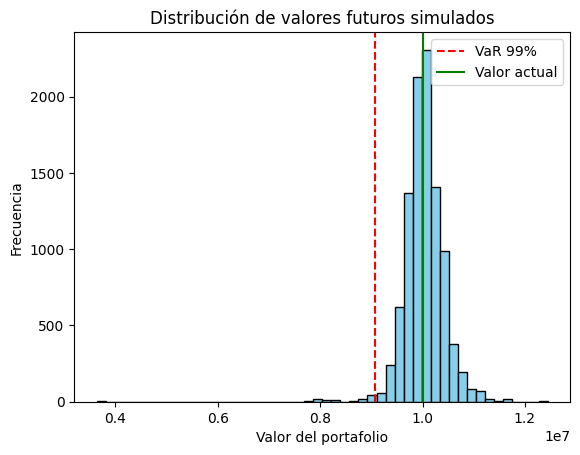

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paso 1: Cargar los retornos diarios históricos
# Supongamos que ya los tenés en un DataFrame llamado 'df' con columna 'returns'

# Ejemplo: simulamos retornos ficticios si no tenés aún
# np.random.seed(42)
# returns = np.random.normal(loc=0.001, scale=0.02, size=1000)
# df = pd.DataFrame({'returns': returns})

# Si ya tenés tu dataframe real:
returns = returns

# Paso 2: Definir parámetros
w0 = 10000000     # Valor actual del portafolio
alpha = 0.01        # Nivel de significancia para 99% de confianza
n_simulaciones = 10000
horizonte_dias = 1

# Paso 3: Simular escenarios futuros con la distribución empírica (bootstrap)
simulaciones = np.random.choice(returns, size=(n_simulaciones, horizonte_dias), replace=True)

# Paso 4: Calcular retornos acumulados por simulación
retornos_simulados = np.sum(simulaciones, axis=1)

# Paso 5: Calcular la distribución del valor futuro
valores_futuros = w0 * (1 + retornos_simulados)

# Paso 6: Calcular el percentil α → el VaR es la pérdida esperada en el peor α%
VaR_empirico = w0 - np.percentile(valores_futuros, alpha * 100)

# Paso 7: Mostrar resultados
print(f"VaR Empírico Monte Carlo a {(1 - alpha)*100:.1f}% de confianza ({horizonte_dias} días): ${VaR_empirico:,.2f}")

# Visualización
plt.hist(valores_futuros, bins=50, color='skyblue', edgecolor='k')
plt.axvline(w0 - VaR_empirico, color='red', linestyle='--', label=f"VaR {int((1-alpha)*100)}%")
plt.axvline(w0, color='green', linestyle='-', label="Valor actual")
plt.title("Distribución de valores futuros simulados")
plt.xlabel("Valor del portafolio")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

### VaR Monte Carlo Normal

In [45]:
# Parametros DIARIOS
datos = returns

def monte_carlo_var_normal(mu, sigma, alpha, h, n_simulaciones):

	sim_returns = norm.rvs(loc=mu, scale=sigma, size=(n_simulaciones, h))

	Z_critico = norm.ppf(1 - alpha)
	var_escenarios = - Z_critico * sigma * np.sqrt(h) + np.sum(sim_returns, axis=1) * h
	
	return var_escenarios

mu = np.mean(datos)
sigma = np.std(datos, ddof=1)
alpha1 = 0.05	# nivel de confianza de 95%
alpha2 = 0.01	# nivel de confianza de 99%
h = 1
n_simulaciones = 100000

var_normal_escenarios1 = monte_carlo_var_normal(mu, sigma, alpha1, h, n_simulaciones)
var_normal_escenarios2 = monte_carlo_var_normal(mu, sigma, alpha2, h, n_simulaciones)
Var_normal_sim1 = np.percentile(var_normal_escenarios1, alpha1*100)
Var_normal_sim2 = np.percentile(var_normal_escenarios2, alpha2*100)

text_custom = f"""
VaR Normal {(1-alpha1) *100:.1f}% de confianza, horizonte temporal {h} días es: {Var_normal_sim1*100:.4f}%.
VaR Normal {(1-alpha2) *100:.1f}% de confianza, horizonte temporal {h} días es: {Var_normal_sim2*100:.4f}%."""
print(text_custom.lstrip())

VaR Normal 95.0% de confianza, horizonte temporal 1 días es: -12.9006%.
VaR Normal 99.0% de confianza, horizonte temporal 1 días es: -18.3271%.


### VaR Monte Carlo t-Student

In [46]:
# Parametros DIARIOS
datos = returns

from scipy.stats import norm, t

def monte_carlo_var_t_student(mu, sigma, nu, alpha, h, n_simulaciones):

	sim_returns = t.rvs(nu, size=(n_simulaciones, h)) * sigma + mu

	t_critico = t.ppf(1 - alpha, df=nu)
	var_escenarios = - t_critico * sigma * np.sqrt(h) + np.sum(sim_returns, axis=1) * h
	
	return var_escenarios

mu = np.mean(datos)
sigma = np.std(datos, ddof=1)
nu, loc, scale = stats.t.fit(datos)
alpha1 = 0.05	# nivel de confianza de 95%
alpha2 = 0.01	# nivel de confianza de 99%
h = 1
n_simulaciones = 10000

var_t_escenarios1 = monte_carlo_var_t_student(mu, sigma, nu, alpha1, h, n_simulaciones)
var_t_escenarios2 = monte_carlo_var_t_student(mu, sigma, nu, alpha2, h, n_simulaciones)
Var_t_sim1 = np.percentile(var_t_escenarios1, alpha1*100)
Var_t_sim2 = np.percentile(var_t_escenarios2, alpha2*100)

text_custom = f"""
VaR t-Student {(1-alpha1) *100:.1f}% de confianza, horizonte temporal {h} días es: {Var_t_sim1*100:.4f}%.
VaR t-Student {(1-alpha2) *100:.1f}% de confianza, horizonte temporal {h} días es: {Var_t_sim2*100:.4f}%."""
print(text_custom.lstrip())

VaR t-Student 95.0% de confianza, horizonte temporal 1 días es: -16.3804%.
VaR t-Student 99.0% de confianza, horizonte temporal 1 días es: -27.9182%.


# Retornos vs Variación % precio

In [47]:
datos = prices
tickers = TICKERS

eje_x = datos.index
x_cat = eje_x.strftime('%Y/%m/%d')

fecha_inicio, fecha_fin = datos.index[[0, -1]]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"
graf_titulo = f'{tickers[0]}: Retornos vs Variacion Log Precio  |  Período {periodo}'
eje_x_titulo = f'Fecha'
eje_y_titulo = f'Retornos'
eje_y_titulo_2 = f'Variacion Log Precio acum.'

# primer día de cada mes + extremos
primeros_dias = eje_x.to_series().groupby(eje_x.year).min().sort_values()
fechas_tick = pd.to_datetime(pd.Index([eje_x.min(), eje_x.max()]).union(primeros_dias)).drop_duplicates().sort_values()

tickvals = fechas_tick.strftime('%Y/%m/%d')		# leyenda en cada tick del graf
ticktext = fechas_tick.strftime('%Y-%m-%d')		# etiquetas eje x


fig_price = go.Figure()

# fig_volat.add_trace(go.Scatter(
# 	x=x_cat,
# 	y=datos,
# 	mode='lines',
# 	line=dict(color='grey', width=1),
# 	name='Retornos'
# ))
fig_price.add_trace(go.Bar(
	x=x_cat,
	y=datos['Return_log'],
	marker=dict(color='grey', 
		line=dict(color='grey', width=1.5)),
	opacity=1,
	name='Log Returns',
	yaxis='y'
))

fig_price.add_trace(go.Scatter(
	x=x_cat,
	y=datos['Close'],
	marker=dict(color='grey', 
		line=dict(color='grey', width=1.5)),
	opacity=1,
	name='Precios',
	yaxis='y2'
))

# line_props = [
# 	{"y": np.full(len(datos), volat_hist), 'color': 'black', "dash": "solid", "text_leg": f'Volat. historica'},
# 	{"y": volat_MA500, 'color': 'purple', "dash": "solid", "text_leg": f'Volat. MA 500'},
# 	{"y": volat_MA40, 'color': 'green', "dash": "solid", "text_leg": f'Volat. MA 40'},
# 	#{y": volat_MA20, 'color': 'purple', "dash": "solid", "text_leg": f'Volat. MA 20 corta'},
# 	{"y": volat_EWMA['vol_ewma'], 'color': 'blue', "dash": "solid", "text_leg": f'Volat. EWMA'},
# 	{"y": volat_GARCH/1, 'color': 'green', "dash": "solid", "text_leg": f'Volat. GARCH Conditional'},
# 	{"y": volat_GARCH_20, 'color': 'orange', "dash": "solid", "text_leg": f'Volat. GARCH 20 Forecast'},
# ]

# for prop in line_props:
# 	fig_volat.add_trace(go.Scatter(
# 		x=x_cat,
# 		y=prop['y'],
# 		mode='lines',
# 		line=dict(color=prop['color'], dash=prop['dash'], width=1),
# 		name=prop['text_leg'],  # Agrega texto a la leyenda
# 		showlegend=True,
# 		yaxis="y2"
# 	))


# Rango de ejes
min_retornos = float(np.min(datos['Return_log']))
max_retornos = float(np.max(datos['Return_log']))
min_prices = float(np.min(datos['Close']))
max_prices = float(np.max(datos['Close']))
rango_y = [min(min_retornos, min_prices), max(max_retornos, max_prices)]


fig_price.update_layout(
    width=1400, height=700, margin=dict(l=40, r=40, t=60, b=40),
    title=graf_titulo,
    title_font=dict(size=22, family="calibri"),
    font=dict(size=12, family="calibri"),
    xaxis=dict(
        title=dict(text=eje_x_titulo, standoff=20),
        type="category", tickmode="array",
        tickvals=tickvals, ticktext=ticktext,
        tickangle=45,
        showticklabels=True,
        showline=True, linewidth=3,
        # categoryorder="array", categoryarray=list(x_cat),
    ),
    # yaxis=dict(title=eje_y_titulo, tickformat=".1%", side="left", range=rango_y),
    # yaxis2=dict(title=eje_y_titulo_2, tickformat=".1%", overlaying="y", side="right", showgrid=False, range=rango_y),
    legend=dict(bordercolor="black", borderwidth=1, x=0.99, y=1.17, xanchor="right", yanchor="top"),
    template="plotly_white"
)

fig_price.show()

# Volatilidad

### 1. Volatilidad historica (fija)

Es la volatilidad que se calcula utilizando toda la muestra.

Por ejemplo, utilizando los retornos diarios de un periodo de 20 años, se obtiene la volatilidad diaria historica de toda la muestra.

In [48]:
volat_hist = np.std(datos, ddof=1)
volat_hist

Open             2.780899e+03
High             2.839254e+03
Low              2.716726e+03
Close            2.777226e+03
Adj Close        2.727045e+03
Volume           1.599336e+06
Return_log       3.995205e-02
Return_simple    3.871978e-02
Volatility_40    2.727246e-01
dtype: float64

### 2. Volatilidad con ventanas moviles

Para calcular la volatilidad, tomamos n retornos diarios pasados.

Podemos calcular a partir de:
1.	**Ventana movil pasada historica**: ventana larga, por ej., 500 dias (2 años).

$$ \sigma_t = \sqrt{ \frac{1}{n-1} * ( \sum_{i=1}^n (\bar{R} - R_i)^2 ) } $$

En este caso, tambien calculamos los retornos con la misma ventana de tiempo.

2.	**Ventana movil pasada corta**: ventana mas corta, por ej., 20 o 40 dias para muestras grandes.

$$ \sigma_t = \sqrt{ \frac{1}{n-1} * ( \sum_{i=1}^n (\bar{R} - R_i)^2 ) } $$

3.	**Ventana movil corta sin centrar**: la usamos en horizontes de tiempo cortos (operaciones con derivados, por ejemplo) y, por lo tanto, no es necesario centrar los datos restando la media.

$$ \sigma_t = \sqrt{ \frac{1}{N} * ( \sum_{i=1}^n (r_i)^2 ) } $$

In [49]:
# Ventana movil 1
datos = returns
window = 500

volat_MA500 = datos.rolling(window=window).std()
volat_MA500

Date
2019-06-03         NaN
2019-06-04         NaN
2019-06-05         NaN
2019-06-06         NaN
2019-06-07         NaN
                ...   
2026-03-26    0.035441
2026-03-27    0.035462
2026-03-30    0.035382
2026-03-31    0.035312
2026-04-01    0.035258
Name: Return_log, Length: 1664, dtype: float64

In [50]:
# Ventana movil 2
datos = returns
window = 40

volat_MA40 = datos.rolling(window=window).std()
volat_MA40

Date
2019-06-03         NaN
2019-06-04         NaN
2019-06-05         NaN
2019-06-06         NaN
2019-06-07         NaN
                ...   
2026-03-26    0.031340
2026-03-27    0.031049
2026-03-30    0.031153
2026-03-31    0.033845
2026-04-01    0.033845
Name: Return_log, Length: 1664, dtype: float64

In [51]:
# Ventana movil 3 corta sin centrar
datos = returns
window = 20

volat_MA20  = datos.rolling(window=window).std()
volat_MA20 = np.sqrt(np.power(datos, 2).rolling(window=window).mean() * MARKET_DAYS_YEAR)
volat_MA20

Date
2019-06-03         NaN
2019-06-04         NaN
2019-06-05         NaN
2019-06-06         NaN
2019-06-07         NaN
                ...   
2026-03-26    0.444095
2026-03-27    0.446919
2026-03-30    0.406078
2026-03-31    0.480192
2026-04-01    0.474791
Name: Return_log, Length: 1664, dtype: float64

### 3. Volatilidad EWMA (RiskMetrics)

*	*Exponentially Weighted Moving Average*. Asume que la volatilidad es heterocedastica (no constante en el tiempo) y los cambios estan autocorrelacionados.

*	La volatilidad esta condicionada por la informacion actual.

$$ \sigma_{t+1}^2 = \lambda * \sigma_t^2  +  (1 - \lambda) * r_t^2 $$

*	$\sigma_{t+1}^2:$ varianza condicional a los retornos pasados.

*	$\lambda:$ factor de persistencia temporal (0<$\lambda$<1), cuanto mas cerca a 1, mayor peso tienen las observaciones pasadas. 

*	$(1 - \lambda) * r_t^2:$ es la contribuciobn del **retorno mas reciente** a la varianza.

*	$\lambda * \sigma_t^2:$ es la parte de la varianza heredada del pasado.

*	Tipicamente se usa $\lambda = 0.94$ para datos diarios, y $\lambda = 0.97$ para datos mensuales.

*	**Valor inicial $\sigma_0$**: se necesita iniciar con, por ejemplo, el desvio de los primeros 40 dias; luego la varainza se actualiza dia a dia.

*	**Volatilidad en t**:

$$ \sigma_t = \sqrt{\sigma_t^2} $$

Este esta OK!!

In [52]:
datos = returns
lambda_ = 0.94
window = 40

volat_EWMA = pd.DataFrame({'vol_ewma': np.nan}, index=datos.index)

vol = np.full(len(datos), np.nan)

var = datos[:window].var(ddof=1)
vol[window - 1] = np.sqrt(var)  # Primer valor de volatilidad EWMA

for t in range(window, len(datos)):
	var = lambda_ * var + (1 - lambda_) * datos.iloc[t-1]**2
	vol[t] = np.sqrt(var)

volat_EWMA["vol_ewma"] = vol

volat_EWMA[37:50]

,vol_ewma
Date,
2019-07-30,NaN
2019-07-31,NaN
2019-08-01,0.032171
2019-08-02,0.031608
2019-08-05,0.030745
2019-08-06,0.029873
2019-08-07,0.029901
2019-08-08,0.029367
2019-08-09,0.028549


Como Function:

In [53]:
def calcular_volat_ewma(datos, lambda_, window):
	volat_EWMA = pd.DataFrame({'vol_ewma': np.nan}, index=datos.index)

	vol = np.full(len(datos), np.nan)

	var = datos[:window].var(ddof=1)
	vol[window - 1] = np.sqrt(var)  # Primer valor de volatilidad EWMA

	for t in range(window, len(datos)):
		var = lambda_ * var + (1 - lambda_) * datos.iloc[t-1]**2
		vol[t] = np.sqrt(var)

	volat_EWMA["vol_ewma"] = vol
	return volat_EWMA 

datos = returns
lambda_ = 0.94
window = 40
volat_EWMA = calcular_volat_ewma(datos, lambda_, window)
volat_EWMA

,vol_ewma
Date,
2019-06-03,NaN
2019-06-04,NaN
2019-06-05,NaN
2019-06-06,NaN
2019-06-07,NaN
...,...
2026-03-26,0.030088
2026-03-27,0.029642
2026-03-30,0.029390


In [54]:
"""datos = returns
lambda_ = 0.94
window = 40
volat_EWMA = pd.DataFrame({
	'retornos': datos,
	'vol_ewma': np.nan
})

var = np.full(len(datos) - (window-1), np.nan)
vol = np.full(len(datos) - (window-1), np.nan)
t = 0

var[t] = volat_EWMA.iloc[:window-0, 0].var(ddof=1)
vol[t] = np.sqrt(var[t])

for t in range(1, len(datos) - (window-1)):
	var[t] = lambda_ * var[t-1] + (1 - lambda_) * volat_EWMA['retornos'].iloc[t+window-2]**2
	vol[t] = np.sqrt(var[t])

completion_array = np.full(window-1, np.nan)
vol = np.concatenate((completion_array, vol))

volat_EWMA['vol_ewma'] = vol

volat_EWMA[37:45]"""

"datos = returns\nlambda_ = 0.94\nwindow = 40\nvolat_EWMA = pd.DataFrame({\n\t'retornos': datos,\n\t'vol_ewma': np.nan\n})\n\nvar = np.full(len(datos) - (window-1), np.nan)\nvol = np.full(len(datos) - (window-1), np.nan)\nt = 0\n\nvar[t] = volat_EWMA.iloc[:window-0, 0].var(ddof=1)\nvol[t] = np.sqrt(var[t])\n\nfor t in range(1, len(datos) - (window-1)):\n\tvar[t] = lambda_ * var[t-1] + (1 - lambda_) * volat_EWMA['retornos'].iloc[t+window-2]**2\n\tvol[t] = np.sqrt(var[t])\n\ncompletion_array = np.full(window-1, np.nan)\nvol = np.concatenate((completion_array, vol))\n\nvolat_EWMA['vol_ewma'] = vol\n\nvolat_EWMA[37:45]"

### 4. Volatilidad Condicional por modelo GARCH

*	*Generelized Autorregressive Conditional Heteroskedasticity*. Asume que la volatilidad es heterocedastica (no constante en el tiempo) y los cambios estan autocorrelacionados.

*	Modela la volatilidad condicional al set de informacion que contiene el historial de retornos del activo.

* 	Ayuda a capturar las *fluctuacions en la volatilidad*.

Esta compuesta por 2 ecuaciones:

**1. Ecuacion de Retornos (media)**:
##### $$ r_t = \mu + \epsilon_t $$

*	$\mu:$ **media condicional**, que puede ser cero o modelada con un ARMA.

*	$\epsilon_t:$ es el **residuo**, con media cero y **volatilidad condicional** $\sigma_t$

*	$\epsilon_t = \sigma_t z_t $ donde $z_t$ ~ $N(0, 1)$. Ruido blanco.


**2. Ecuacion de la Volatilidad (varianza condicional)**:

##### $$ \sigma_t^2 = w + \sum_{i=1}^q \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2 $$

*	$\sigma_{t}^2$ es la **volatilidad condicional** en el tiempo j.

*	$w > 0$ es un **termino constante**.

*	$\alpha_i$ mide el impacto de **shocks pasados** ($\epsilon_{t-i}^2$).

*	$\beta_j$ mide la **persistencia** de la volatilidad pasada ($\sigma_{t-j}^2$).

**Condicion de estacionariedad**:

Para que la varianza condicional sea finita, se debe cumplir:

$$ \sum_{i=1}^q \alpha_i + \sum_{j=1}^p \beta_j < 1 $$

Ya que, si esta cerca de 1, la volatilidad tiene memoria larga.


**Interpretacion de los parametros:**

1.	$\alpha_i$ es grande => la volatilidad responde fuertemente a **shocks recientes**.

2.	$\beta_j$ es grande => la volatilidad es **persistente** (tarda en disiparse).

3.	$\alpha_i + \beta_j$ es cercano a 1 => la volatilidad es **altamente persistente** (carcateristicos de los mercados financieros).

**¿Cual usamos?**

*	Si buscamos **analizar** la **volatilidad condicional** pasada **sin hacer predicciones** => usamos `result.conditional_volatility`:

	*	 Ajusta un **único modelo GARCH** a **toda la serie** de datos y devuelve la **volatilidad** condicional estimada para **cada punto**.

*	Si buscamos **predecir dinamicamente** la **volatilidad futura** => usamos `result.forecast(horizon=1)`:

	*	Utiliza una **ventana móvil de 20** días, **ajustando un modelo GARCH en cada paso** y **estimando** la **volatilidad** solo para el **día siguiente**.

#### **Ejemplo de GARCH(1,1)** `result.conditional_volatility`:

Ajustamos un **único modelo GARCH** a **toda la serie** de datos y devuelve la **volatilidad** condicional estimada para **cada punto**.

In [55]:
from arch import arch_model

datos = returns
h = 10

# Definimos el modelo GARCH(1,1)
garch_model = arch_model(datos*100, vol='GARCH', p=1, q=1, mean='Zero')

# Ajustamos el modelo
result = garch_model.fit(disp='off')
print(result)

# Volatilidad condicional estimada
volat_garch = np.sqrt(result.conditional_volatility)
volat_garch = volat_garch/100

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             Return_log   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -4542.96
Distribution:                  Normal   AIC:                           9091.92
Method:            Maximum Likelihood   BIC:                           9108.18
                                        No. Observations:                 1664
Date:                Thu, Sep 10 2026   Df Residuals:                     1664
Time:                        01:10:13   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          3.1735      1.996      1.590      0.112   [ -0.73

In [56]:
#print(f'{volat_garch}\n')
volat_garch

Date
2019-06-03    0.022840
2019-06-04    0.020484
2019-06-05    0.021349
2019-06-06    0.020139
2019-06-07    0.019224
                ...   
2026-03-26    0.018917
2026-03-27    0.018400
2026-03-30    0.018335
2026-03-31    0.017672
2026-04-01    0.022992
Name: cond_vol, Length: 1664, dtype: float64

Pronostico a *h* dias

In [57]:
# Pronostico a h dias
forecast = result.forecast(start=len(datos)-1, horizon=h)
volat_forecast = np.sqrt(forecast.variance.iloc[-1])

print(volat_forecast)

h.01    4.241953
h.02    4.308160
h.03    4.363977
h.04    4.411146
h.05    4.451083
h.06    4.484952
h.07    4.513711
h.08    4.538158
h.09    4.558959
h.10    4.576671
Name: 2026-04-01 00:00:00, dtype: float64


#### Function:

In [58]:
def calcular_volat_garch_cond(datos, p, q):
	multip = 100
	garch_model = arch_model(datos*multip, vol='GARCH', p=p, q=q, mean='Zero')
	# Ajustamos el modelo
	result = garch_model.fit(disp='off')
	# Volatilidad condicional estimada
	volat_garch = np.sqrt(result.conditional_volatility)
	volat_garch = volat_garch/multip
	return volat_garch


In [59]:
datos = returns
p = 1
q = 1

volat_GARCH = calcular_volat_garch_cond(datos, p, q)
volat_GARCH

Date
2019-06-03    0.022840
2019-06-04    0.020484
2019-06-05    0.021349
2019-06-06    0.020139
2019-06-07    0.019224
                ...   
2026-03-26    0.018917
2026-03-27    0.018400
2026-03-30    0.018335
2026-03-31    0.017672
2026-04-01    0.022992
Name: cond_vol, Length: 1664, dtype: float64

#### **Ejemplo de GARCH(1,1)** `result.forecast(horizon=1)`:

Utiliza una **ventana móvil de 20** días, **ajustando un modelo GARCH en cada paso** y **estimando** la **volatilidad** solo para el **día siguiente**.

Codigo simple

In [60]:
# Lo comento para que no se ejecute, ya que se logra el mismo resultado mas abajo y de forma mas eficiente.

"""import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

datos = returns.to_numpy()
window_size = 20

data = pd.DataFrame({'returns': datos*1000})
volatility_estimated = []

for i in range(window_size, len(datos)):
	# Tomar ventana de 20 días previos
	train_data = data['returns'][i-window_size:i]
	
	# Ajustar modelo GARCH(1,1)
	modelo_garch = arch_model(train_data, vol='GARCH', p=1, q=1, mean='zero')
	resultado = modelo_garch.fit(disp='off')

	# Predecir la volatilidad del día siguiente
	forecast = resultado.forecast(horizon=1)
	vol_next_day = np.sqrt(forecast.variance.iloc[-1, 0])  # Volatilidad condicional estimada
	
	# Guardar volatilidad estimada
	volatility_estimated.append(vol_next_day)

# Convertir lista a serie de Pandas para alinearla con los datos originales
data['vol_garch'] = np.nan
data.loc[window_size:, 'vol_garch'] = volatility_estimated
data = data/1000
data"""

"import numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom arch import arch_model\n\ndatos = returns.to_numpy()\nwindow_size = 20\n\ndata = pd.DataFrame({'returns': datos*1000})\nvolatility_estimated = []\n\nfor i in range(window_size, len(datos)):\n\t# Tomar ventana de 20 días previos\n\ttrain_data = data['returns'][i-window_size:i]\n\t\n\t# Ajustar modelo GARCH(1,1)\n\tmodelo_garch = arch_model(train_data, vol='GARCH', p=1, q=1, mean='zero')\n\tresultado = modelo_garch.fit(disp='off')\n\n\t# Predecir la volatilidad del día siguiente\n\tforecast = resultado.forecast(horizon=1)\n\tvol_next_day = np.sqrt(forecast.variance.iloc[-1, 0])  # Volatilidad condicional estimada\n\t\n\t# Guardar volatilidad estimada\n\tvolatility_estimated.append(vol_next_day)\n\n# Convertir lista a serie de Pandas para alinearla con los datos originales\ndata['vol_garch'] = np.nan\ndata.loc[window_size:, 'vol_garch'] = volatility_estimated\ndata = data/1000\ndata"

Codigo con GridSearch, metricas y paralelizacion

In [61]:
from arch import arch_model
from joblib import Parallel, delayed
from itertools import product
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Función para entrenar GARCH en una ventana móvil
def fit_garch_window(i, data, p, q):
	train_data = data[i - window:i]  # Tomamos la ventana móvil
	model = arch_model(train_data, vol='GARCH', p=p, q=q, mean='zero')
	result = model.fit(disp='off')
	forecast = result.forecast(horizon=1)
	return np.sqrt(forecast.variance.iloc[-1, 0])  # Volatilidad estimada

# Grid Search para seleccionar (p, q) óptimos
def optimize_garch(data):
	best_p, best_q, best_rmse = None, None, float('inf')
	for p, q in product(p_values, q_values):
		vol_estimated = Parallel(n_jobs=-1)(delayed(fit_garch_window)(i, data, p, q) for i in range(window, len(data)))
		rmse = mean_squared_error(data[window:], vol_estimated, squared=False)  # RMSE entre retornos y volatilidad estimada
		if rmse < best_rmse:
			best_p, best_q, best_rmse = p, q, rmse
	return best_p, best_q


In [62]:
multip = 1000
datos = returns.to_numpy()*multip
datos_fecha = returns
window = 20 
best_p, best_q = 1, 1

"""
p_values = [1, 2]  # Posibles valores de p
q_values = [1, 2]  # Posibles valores de q

# Encontramos los mejores p y q
best_p, best_q = optimize_garch(datos)"""

print(f"Mejores parámetros: p={best_p}, q={best_q}")

Mejores parámetros: p=1, q=1


In [63]:
# Estimamos la volatilidad con los mejores parámetros
volatility_estimated = Parallel(n_jobs=-1)(delayed(fit_garch_window)(i, datos, best_p, best_q) for i in range(window, len(datos)))


In [64]:
# Guardamos los resultados en un DataFrame
result_eval = pd.DataFrame({'returns': returns})
result_eval['vol_garch'] = np.nan
result_eval.iloc[window:, result_eval.columns.get_loc('vol_garch')] = volatility_estimated
result_eval['vol_garch'] = result_eval['vol_garch'] / multip

# Evaluamos la predicción
rmse_final = root_mean_squared_error(result_eval['returns'][window:], result_eval['vol_garch'][window:])#, squared=False)
print(f"RMSE final del modelo GARCH: {rmse_final}")


RMSE final del modelo GARCH: 0.05568594075510653


In [65]:
result_eval

,returns,vol_garch
Date,,
2019-06-03,0.000000,NaN
2019-06-04,0.050445,NaN
2019-06-05,0.026367,NaN
2019-06-06,0.023271,NaN
2019-06-07,-0.006072,NaN
...,...,...
2026-03-26,-0.021473,0.027768
2026-03-27,-0.025119,0.027667
2026-03-30,0.013423,0.027212


In [66]:
volat_GARCH_20 = result_eval.copy()
volat_GARCH_20.drop(columns=['returns'], errors='ignore', inplace=True)

volat_GARCH_20

,vol_garch
Date,
2019-06-03,NaN
2019-06-04,NaN
2019-06-05,NaN
2019-06-06,NaN
2019-06-07,NaN
...,...
2026-03-26,0.027768
2026-03-27,0.027667
2026-03-30,0.027212


In [67]:
volat_GARCH_20

,vol_garch
Date,
2019-06-03,NaN
2019-06-04,NaN
2019-06-05,NaN
2019-06-06,NaN
2019-06-07,NaN
...,...
2026-03-26,0.027768
2026-03-27,0.027667
2026-03-30,0.027212


In [68]:
volat_GARCH_20 = volat_GARCH_20['vol_garch']
volat_GARCH_20

Date
2019-06-03         NaN
2019-06-04         NaN
2019-06-05         NaN
2019-06-06         NaN
2019-06-07         NaN
                ...   
2026-03-26    0.027768
2026-03-27    0.027667
2026-03-30    0.027212
2026-03-31    0.025677
2026-04-01    0.035692
Name: vol_garch, Length: 1664, dtype: float64

#### Function:

In [69]:
def calcular_volat_garch_window(datos, p, q, window):
	multip = 100
	datos = datos.to_numpy()*multip
	datos_fecha = returns
	best_p, best_q = p, q
	
	volatility_estimated = Parallel(n_jobs=-1)(delayed(fit_garch_window)(i, datos, best_p, best_q) for i in range(window, len(datos)))

	#volat_GARCH_20 = pd.DataFrame({'fecha': datos_fecha.index[window:]})
	volat_GARCH_20 = pd.DataFrame({'fecha': datos_fecha.index})
	volat_GARCH_20['fecha'] = pd.to_datetime(volat_GARCH_20['fecha'])
	volat_GARCH_20.set_index('fecha', inplace=True)

	volat_GARCH_20['vol_garch'] = np.nan
	volat_GARCH_20.iloc[window:, volat_GARCH_20.columns.get_loc('vol_garch')] = volatility_estimated
	#volat_GARCH_20.iloc[:, volat_GARCH_20.columns.get_loc('vol_garch')] = volatility_estimated
	volat_GARCH_20['vol_garch'] = volat_GARCH_20['vol_garch'] / multip

	volat_GARCH_20 = volat_GARCH_20['vol_garch']

	return volat_GARCH_20


In [70]:
datos = returns
window = 20
p = 1
q = 1

volat_GARCH_20 = calcular_volat_garch_window(datos, p, q, window)
volat_GARCH_20

fecha
2019-06-03         NaN
2019-06-04         NaN
2019-06-05         NaN
2019-06-06         NaN
2019-06-07         NaN
                ...   
2026-03-26    0.027768
2026-03-27    0.027178
2026-03-30    0.026811
2026-03-31    0.026534
2026-04-01    0.035693
Name: vol_garch, Length: 1664, dtype: float64

### 5. Comparamos los distintos metodos de calculo de la Volatilidad y los Retornos

In [71]:
datos = returns
tickers = TICKERS

eje_x = datos.index
x_cat = eje_x.strftime('%Y/%m/%d')

fecha_inicio, fecha_fin = datos.index[[0, -1]]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"
graf_titulo = f'{tickers[0]}: Retornos vs Volatilidades  |  Período {periodo}'
eje_x_titulo = f'Fecha'
eje_y_titulo = f'Retornos'
eje_y_titulo_2 = f'Volalitidad'

# primer día de cada mes + extremos
primeros_dias = eje_x.to_series().groupby(eje_x.year).min().sort_values()
fechas_tick = pd.to_datetime(pd.Index([eje_x.min(), eje_x.max()]).union(primeros_dias)).drop_duplicates().sort_values()

tickvals = fechas_tick.strftime('%Y/%m/%d')		# leyenda en cada tick del graf
ticktext = fechas_tick.strftime('%Y-%m-%d')		# etiquetas eje x


fig_volat = go.Figure()

# fig_volat.add_trace(go.Scatter(
# 	x=x_cat,
# 	y=datos,
# 	mode='lines',
# 	line=dict(color='grey', width=1),
# 	name='Retornos'
# ))
fig_volat.add_trace(go.Bar(
	x=x_cat,
	y=datos,
	marker=dict(color='grey', 
		line=dict(color='grey', width=1.5)),
	opacity=1,
	name='Retornos',
))

line_props = [
	# {"y": np.full(len(datos), volat_hist), 'color': 'black', "dash": "solid", "text_leg": f'Volat. historica'},
	{"y": volat_MA500, 'color': 'purple', "dash": "solid", "text_leg": f'Volat. MA 500'},
	{"y": volat_MA40, 'color': 'green', "dash": "solid", "text_leg": f'Volat. MA 40'},
	#{y": volat_MA20, 'color': 'purple', "dash": "solid", "text_leg": f'Volat. MA 20 corta'},
	{"y": volat_EWMA['vol_ewma'], 'color': 'blue', "dash": "solid", "text_leg": f'Volat. EWMA'},
	{"y": volat_GARCH/1, 'color': 'green', "dash": "solid", "text_leg": f'Volat. GARCH Conditional'},
	{"y": volat_GARCH_20, 'color': 'orange', "dash": "solid", "text_leg": f'Volat. GARCH 20 Forecast'},
]

for prop in line_props:
	fig_volat.add_trace(go.Scatter(
		x=x_cat,
		y=prop['y'],
		mode='lines',
		line=dict(color=prop['color'], dash=prop['dash'], width=1),
		name=prop['text_leg'],  # Agrega texto a la leyenda
		showlegend=True,
		yaxis="y2"
	))

min_retornos = np.min(datos)
max_retornos = np.max(datos)

min_volatilidad = min([np.min(prop["y"]) for prop in line_props])
max_volatilidad = max([np.max(prop["y"]) for prop in line_props])

min_valor = min(min_retornos, min_volatilidad)
max_valor = max(max_retornos, max_volatilidad)

rango_y = [min_valor, max_valor]

fig_volat.update_layout(
	width=1400, height=700, margin=dict(l=40, r=40, t=60, b=40),
	title=graf_titulo, 
	title_font=dict(size=22, family="calibri"),
	font=dict(size=13, family="calibri"),
	xaxis=dict(title=dict(text=eje_x_titulo, standoff=20), type='category', tickmode='array', tickvals=tickvals, ticktext=ticktext, tickangle=45, showticklabels=True, showline=True, linewidth=1,),	
	yaxis=dict(title=eje_y_titulo, tickformat=".1%", side='left', range=rango_y), 
	yaxis2=dict(title=eje_y_titulo_2, tickformat=".1%", overlaying='y', side='right', showgrid=False, range=rango_y),
	legend=dict(bordercolor="black", borderwidth=1, x=0.98, y=1.18, xanchor="right", yanchor="top"),
	template='plotly_white'
)

fig_volat.show()
fig_volat.write_html("Volatilidad.html")

# Backtesting

In [72]:
from arch import arch_model

def calcular_var_volat_hist(datos, alpha, h):
	Z_critico = norm.ppf(1 - alpha)
	mu = np.mean(datos)
	volat_hist = np.std(datos, ddof=1)
	sigma = volat_hist
	
	VaR_hist = - Z_critico * sigma * np.sqrt(h) + mu * h
	return VaR_hist

def calcular_var_volat_MA(datos, alpha, h, window):
	Z_critico = norm.ppf(1 - alpha)
	mu_t = datos.rolling(window=window).mean()
	volat_MA = datos.rolling(window=window).std(ddof=1)
	sigma_t = volat_MA

	VaR_MA = - Z_critico * sigma_t * np.sqrt(h) + mu_t * h	
	return VaR_MA
	
def calcular_var_volat_ewma(datos, alpha, h, window, lambda_):
	Z_critico = norm.ppf(1 - alpha)
	volat_ewma = calcular_volat_ewma(datos, lambda_, window)
	volat_ewma = volat_ewma.squeeze()
	mu_t = datos.rolling(window=window).mean()

	sigma_T = volat_ewma
	mu_T = mu_t
	VaR_EWMA = -Z_critico * sigma_T * np.sqrt(h) + mu_T * h
	return VaR_EWMA

def calcular_var_volat_garch_cond(datos, alpha, h, window, p, q):
	Z_critico = norm.ppf(1 - alpha)
	mu_t = datos.rolling(window=window).mean()
	sigma_t = calcular_volat_garch_cond(datos, p, q)

	VaR_GARCH = -Z_critico * sigma_t * np.sqrt(h) + mu_t * h
	return VaR_GARCH

def calcular_var_volat_garch_20_forecast(datos, alpha, h, window_mu, window, p, q):
	Z_critico = norm.ppf(1 - alpha)
	mu_t = datos.rolling(window=window_mu).mean()
	sigma_t = calcular_volat_garch_window(datos, p, q, window)

	VaR_GARCH_20 = -Z_critico * sigma_t * np.sqrt(h) + mu_t * h
	return VaR_GARCH_20


In [73]:
datos = returns
alpha = 0.01
h = 1

VaR_hist = calcular_var_volat_hist(datos, alpha, h)

window = 500
VaR_MA500 = calcular_var_volat_MA(datos, alpha, h, window)

window = 40
VaR_MA40 = calcular_var_volat_MA(datos, alpha, h, window)

window = 40
lambda_ = 0.94
VaR_EWMA = calcular_var_volat_ewma(datos, alpha, h, window, lambda_)

window = 40
p = 1
q = 1
# VaR_GARCH_cond = calcular_var_volat_garch_cond(datos, alpha, h, window, p, q)

window = 20
window_mu = 40
# window_mu = 20
p = 1
q = 1
VaR_GARCH_20_forecast = calcular_var_volat_garch_20_forecast(datos, alpha, h, window_mu, window, p, q)


#### Retornos y VaR

In [74]:
datos = returns
tickers = TICKERS

eje_x = datos.index
x_cat = eje_x.strftime('%Y/%m/%d')

fecha_inicio, fecha_fin = datos.index[[0, -1]]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"
graf_titulo = f'{tickers[0]}: Retornos vs Value at Risk \u03B1={alpha * 100:.1f}%, h={h} días | {periodo}'
eje_x_titulo = f'Fecha'
eje_y_titulo = f'Retornos'
eje_y_titulo_2 = f'Value at Risk'

# primer dia de cada año y cada 2do semestre
years = pd.Index(eje_x.year.unique()).sort_values()
candidates = pd.DatetimeIndex(
    [pd.Timestamp(int(y), 1, 1) for y in years] +
    [pd.Timestamp(int(y), 7, 1) for y in years]
).unique().sort_values()
snapped = pd.DatetimeIndex(eje_x[eje_x.get_indexer(candidates, method='nearest')])
fechas_tick = snapped.union(pd.DatetimeIndex([eje_x.min(), eje_x.max()])).unique().sort_values()

tickvals = fechas_tick.strftime('%Y/%m/%d')
ticktext = fechas_tick.strftime('%Y-%m-%d')


fig_VaR = go.Figure()

fig_VaR.add_trace(go.Bar(
	x=x_cat,
	y=datos,
	marker=dict(color='grey', 
		line=dict(color='grey', width=1.5)),
	opacity=1,
	name='Retornos',
))

line_props = [
	# {"y": np.full(len(datos), VaR_hist), 'color': 'black', "dash": "solid", "text_leg": f'VaR historica'},
	# {"y": VaR_MA500, 'color': 'purple', "dash": "solid", "text_leg": f'VaR MA 500'},
	# {"y": VaR_MA40, 'color': 'green', "dash": "solid", "text_leg": f'VaR MA 40'},
	{"y": VaR_EWMA, 'color': 'blue', "dash": "solid", "text_leg": f'VaR EWMA'},
	# {"y": VaR_GARCH_cond, 'color': 'green', "dash": "solid", "text_leg": f'VaR GARCH Conditional'},
	{"y": VaR_GARCH_20_forecast, 'color': 'orange', "dash": "solid", "text_leg": f'VaR GARCH 20 Forecast'},
]

for prop in line_props:
	fig_VaR.add_trace(go.Scatter(
		x=x_cat,
		y=prop['y'],
		mode='lines',
		line=dict(color=prop['color'], dash=prop['dash'], width=1),
		name=prop['text_leg'],  # Agrega texto a la leyenda
		showlegend=True,
		yaxis="y2"
	))

min_retornos = np.min(datos)
max_retornos = np.max(datos)

min_volatilidad = min([np.min(prop["y"]) for prop in line_props])
max_volatilidad = max([np.max(prop["y"]) for prop in line_props])

min_valor = min(min_retornos, min_volatilidad)
max_valor = max(max_retornos, max_volatilidad)

rango_y = [min_valor, max_valor]

fig_VaR.update_layout(
	width=1400, height=700, margin=dict(l=40, r=40, t=60, b=40),
	title=graf_titulo,
	title_font=dict(size=22, family="calibri"),
	font=dict(size=13, family="calibri"),
	xaxis=dict(title=dict(text=eje_x_titulo, standoff=20), type='category', tickmode='array', tickvals=tickvals, ticktext=ticktext, tickangle=45, showticklabels=True, showline=True, linewidth=1,),
	yaxis=dict(title=eje_y_titulo, tickformat=".1%", side='left', range=rango_y), 
	yaxis2=dict(title=eje_y_titulo_2, tickformat=".1%", overlaying='y', side='right', showgrid=False, range=rango_y),
	legend=dict(bordercolor="black", borderwidth=1, x=0.99, y=1.170, xanchor="right", yanchor="top"),
	template='plotly_white'
)

fig_VaR.show()
fig_VaR.write_html("VaR.html")

In [75]:
COLOR_ALT_1 = "rgba(200,50,50,0.60)"
COLOR_ALT_2 = "rgba(50,90,200,0.60)"

datos = returns                # Serie o array de retornos (index datetime)
tickers = TICKERS

eje_x = datos.index
x_cat = eje_x.strftime("%Y/%m/%d")  # eje categórico con fechas como string (mantiene orden de aparición)

fecha_inicio, fecha_fin = datos.index[[0, -1]]
periodo = f"{fecha_inicio.strftime('%Y-%b')} - {fecha_fin.strftime('%Y-%b')}"
graf_titulo = f'{tickers[0]}: Retornos vs Value at Risk \u03B1={alpha * 100:.1f}%, h={h} días | {periodo}'
eje_x_titulo = 'Fecha'
eje_y_titulo = 'Retornos'
eje_y_titulo_2 = 'Value at Risk'


# primer dia de cada año y cada 2do semestre
idx_anio = pd.DatetimeIndex(eje_x.to_series().groupby(eje_x.year).min().values)
mask_sem2 = eje_x.month >= 7
idx_sem2 = pd.DatetimeIndex(
    eje_x[mask_sem2].to_series().groupby(eje_x[mask_sem2].year).min().values)
fechas_tick = (pd.DatetimeIndex([eje_x.min(), eje_x.max()])
            	.union(idx_anio)#.union(idx_sem2)
                .unique().sort_values())


hechos = reasignar_fechas_hechos(hechos, x_cat)
hechos["MostrarEnEjeX"] = hechos["MostrarEnEjeX"].fillna(False).astype(bool)

if "Color" not in hechos.columns:
    n = len(hechos)
    hechos["Color"] = np.where((np.arange(n) % 2) == 0, COLOR_ALT_1, COLOR_ALT_2)

# Fechas de hechos seleccionadas para el eje X
fechas_hechos = pd.to_datetime(hechos.loc[hechos["MostrarEnEjeX"], "FechaGraficada"]).sort_values()
fechas_combinadas = pd.to_datetime(pd.Index(fechas_tick).union(fechas_hechos)).drop_duplicates().sort_values()

tickvals = fechas_combinadas.strftime('%Y/%m/%d')
ticktext = fechas_combinadas.strftime('%Y-%m-%d')


fig_VaR = go.Figure()

# Barras de retornos
fig_VaR.add_trace(go.Bar(
    x=x_cat,
    y=datos,
    marker=dict(color='grey', line=dict(color='grey', width=1.2)),
    opacity=1,
    name='Retornos',
))

# Líneas de VaR (eje derecho)
line_props = [
    {"y": VaR_EWMA,               "color": "blue",   "dash": "solid", "text_leg": "VaR EWMA"},
    {"y": VaR_GARCH_20_forecast,  "color": "orange", "dash": "solid", "text_leg": "VaR GARCH 20 Forecast"},
]
for prop in line_props:
    fig_VaR.add_trace(go.Scatter(
        x=x_cat,
        y=prop["y"],
        mode="lines",
        line=dict(color=prop["color"], dash=prop["dash"], width=1),
        name=prop["text_leg"],
        showlegend=True,
        yaxis="y2"
    ))


# Lineas verticales
# Posiciones en 'paper' para escalonar anotaciones (0=abajo, 1=arriba)
y_bandas = np.linspace(0.42, 0.1, 4)  # 5 niveles
# offset = 0.17 * (max(datos) - min(datos))  # desplazamiento vertical base
hechos_ordenados = hechos.sort_values("FechaGraficada")

for i, fila in hechos_ordenados.iterrows():
    f_g = pd.to_datetime(fila["FechaGraficada"])
    fecha_str = f_g.strftime("%Y/%m/%d")
    descripcion = fila["Hecho relevante"]
    color_linea = fila["Color"]

    # Alinear el texto cerca de extremos
    if f_g >= eje_x.max() - pd.Timedelta(days=270):
        xanchor = "right"
    elif f_g <= eje_x.min() + pd.Timedelta(days=180):
        xanchor = "left"
    else:
        xanchor = "left"

    # Línea vertical (color específico para cada hecho)
    fig_VaR.add_vline(
        x=fecha_str,
        line=dict(color=color_linea, width=1, dash="dot"),
        layer="above",
    )

    # Anotación (usar 'paper' en Y para independencia de escala)
    y_pos = float(y_bandas[i % len(y_bandas)])
    fig_VaR.add_annotation(
        x=fecha_str,
        y=y_pos,
        xref="x",
        yref="paper",
        text=f"<b>{fila['FechaGraficada'].strftime('%Y-%m-%d')}</b><br>{wrap_text_for_plotly(descripcion, 13)}",
        xanchor=xanchor, yanchor="bottom",
        font=dict(size=11, color="black", family="calibri"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor=color_linea,
        borderwidth=0.8,
        borderpad=3,
        showarrow=False,
        width=56,
        height=40,
        valign="top",
        align="left",
    )

# # --- líneas verticales suaves para el 1-ene de cada año (debajo de las trazas) ---
# idx_anio = pd.DatetimeIndex(eje_x.to_series().groupby(eje_x.year).min().values)  # 1.º día presente de cada año
# for x in idx_anio.strftime("%Y/%m/%d"):
#     fig_VaR.add_vline(
#         x=x,
#         line=dict(color="rgba(0,0,0,0.22)", width=1),  # gris tenue, profesional
#         layer="below"  # bajo las barras y líneas de VaR
#     )


# Rango de ejes
min_retornos = float(np.min(datos))
max_retornos = float(np.max(datos))
min_volatilidad = float(min(np.min(p["y"]) for p in line_props))
max_volatilidad = float(max(np.max(p["y"]) for p in line_props))
rango_y = [min(min_retornos, min_volatilidad), max(max_retornos, max_volatilidad)]


fig_VaR.update_layout(
    width=1400, height=700, margin=dict(l=40, r=40, t=60, b=40),
    title=graf_titulo,
    title_font=dict(size=22, family="calibri"),
    font=dict(size=12, family="calibri"),
    xaxis=dict(
        title=dict(text=eje_x_titulo, standoff=20),
        type="category", tickmode="array",
        tickvals=tickvals, ticktext=ticktext,
        tickangle=45,
        showticklabels=True,
        showline=True, linewidth=3,
        # categoryorder="array", categoryarray=list(x_cat),
    ),
    yaxis=dict(title=eje_y_titulo, tickformat=".1%", side="left", range=rango_y),
    yaxis2=dict(title=eje_y_titulo_2, tickformat=".1%", overlaying="y", side="right", showgrid=False, range=rango_y),
    legend=dict(bordercolor="black", borderwidth=1, x=0.99, y=1.17, xanchor="right", yanchor="top"),
    template="plotly_white"
)

fig_VaR.show()
fig_VaR.write_html("VaR_con_eventos.html")